# GNN Architecture Comparison + XAI Study
### SAGE | GCN | GAT | GIN — Patient Health Score Prediction
---
**Pipeline:**
1. RDF loading → patient feature engineering (38 dims)
2. KNN patient-patient graph (k=10, cosine similarity)
3. Train & compare 4 GNN architectures
4. Save all models, auto-select best
5. XAI comparative study (GNNExplainer | GraphMask | ZORRO) on best model

In [ ]:
!pip install pandas networkx matplotlib torch-geometric rdflib scikit-learn scipy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 37.5 MB/s eta 0:00:00


In [ ]:
import rdflib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import os, warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from copy import deepcopy
from torch_geometric.data import Data
from torch_geometric.nn import MessagePassing, GCNConv, GATConv, SAGEConv
from torch_geometric.explain import Explainer, GNNExplainer, ModelConfig
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr
warnings.filterwarnings('ignore')
os.makedirs('saved_models', exist_ok=True)
print('✅ Imports OK')

✅ Imports OK


## 1. Data Loading

In [ ]:
def load_rdf(rdf_file):
    g = rdflib.Graph()
    g.parse(rdf_file, format='turtle')
    print(f'✅ {len(g)} triples loaded')
    graph = {}
    for subj, pred, obj in g:
        subj = str(subj)
        pname = str(pred).split('#')[-1]
        graph.setdefault(subj, {'predicates': {}, 'type': None})
        if pname == 'type':
            graph[subj]['type'] = str(obj).split('#')[-1]
        else:
            graph[subj]['predicates'].setdefault(pname, [])
            graph[subj]['predicates'][pname].append(
                obj.value if isinstance(obj, rdflib.Literal) else str(obj))
    return graph

def safe_float(v):
    try: return float(v)
    except: return 0.0

def extract_patient(graph, pid):
    d = graph.get(pid)
    if not d: return None
    basic = {k: safe_float(d['predicates'].get(k,[None])[0])
             for k in ['age','weight','height','mood','stressLevel']}
    fuzzy = {}
    for mn in d['predicates'].get('hasMeasurement',[]):
        for k,v in graph.get(mn,{}).get('predicates',{}).items():
            if k.startswith(('Low','Medium','High')):
                fuzzy[k] = float(v[0])
    score = 0.0
    for sl in d['predicates'].get('hasScore',[]):
        s = graph.get(sl,{}).get('predicates',{})
        try: score = float(s.get('value',[0.0])[0])
        except: pass
        fuzzy.update({k: float(v[0]) for k,v in s.items() if 'Score' in k})
    return {'id': pid.split('#')[-1], 'basic': basic,
            'fuzzy': fuzzy, 'score': score}

def extract_all(graph):
    return [p for nid,d in graph.items() if d.get('type')=='Patient'
            for p in [extract_patient(graph, nid)] if p]

print('✅ RDF functions defined')

✅ RDF functions defined


## 2. Feature Engineering & KNN Graph

- **38 features per patient**: 5 basic + 33 fuzzy membership values
- **Edges**: k=10 nearest neighbors by cosine similarity on fuzzy profile
- **Edge weight**: cosine similarity (similar patients → stronger message)

In [ ]:
def build_pyg(patients, max_p=10000, k=10,
              train_r=0.7, val_r=0.15, seed=42):
    np.random.seed(seed)
    patients = patients[:max_p]
    n = len(patients)

    # Fixed fuzzy key order — use fk to avoid shadowing k
    fkeys = sorted({fk for p in patients for fk in p['fuzzy']})
    fidx  = {fk: i for i, fk in enumerate(fkeys)}
    nf    = len(fkeys)
    print(f'📌 Fuzzy dims: {nf}  |  Total features: {5+nf}')

    # Feature matrix — use bk for basic keys, fk for fuzzy keys
    bkeys = ['age', 'weight', 'height', 'mood', 'stressLevel']
    X, y  = [], []
    for p in patients:
        fvec = [0.0] * nf
        for fk, w in p['fuzzy'].items():
            if fk in fidx:
                fvec[fidx[fk]] = w
        X.append([p['basic'].get(bk, 0.) for bk in bkeys] + fvec)
        y.append(p['score'])
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    print(f'📈 Score range: {y.min():.1f}–{y.max():.1f}  '
          f'mean={y.mean():.1f}  std={y.std():.1f}')

    # KNN graph on fuzzy profile — k is now safe (never overwritten)
    print(f'⏳ KNN graph (k={k}, cosine)...')
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='brute', metric='cosine')
    nbrs.fit(X[:, 5:])
    dist, nbr_idx = nbrs.kneighbors(X[:, 5:])
    src = np.repeat(np.arange(n), k)
    dst = nbr_idx[:, 1:].flatten()
    wts = np.clip(1. - dist[:, 1:].flatten(), 0., 1.).astype(np.float32)
    # bidirectional
    src = np.concatenate([src, dst])
    dst = np.concatenate([dst, nbr_idx[:, 1:].flatten()])
    wts = np.concatenate([wts, wts])
    edge_index  = torch.tensor(np.stack([src, dst]), dtype=torch.long)
    edge_weight = torch.tensor(wts, dtype=torch.float)
    print(f'✅ {n} nodes  {edge_index.shape[1]} edges')

    # Scale
    x = torch.tensor(StandardScaler().fit_transform(X), dtype=torch.float)
    y = torch.tensor(y, dtype=torch.float)

    # Split
    order = np.random.permutation(n)
    n_tr  = int(n * train_r)
    n_vl  = int(n * val_r)
    tm = torch.zeros(n, dtype=torch.bool)
    vm = torch.zeros(n, dtype=torch.bool)
    em = torch.zeros(n, dtype=torch.bool)
    tm[order[:n_tr]] = True
    vm[order[n_tr:n_tr+n_vl]] = True
    em[order[n_tr+n_vl:]] = True

    data = Data(x=x, edge_index=edge_index,
                edge_attr=edge_weight.unsqueeze(1),
                edge_weight=edge_weight,
                y=y, train_mask=tm, val_mask=vm, test_mask=em)
    feat_names = bkeys + fkeys
    pat_names  = [p['id'] for p in patients]
    return data, feat_names, pat_names

print('✅ build_pyg defined')

✅ build_pyg defined


In [ ]:
graph_data   = load_rdf('fullKG (2).ttl')
all_patients = extract_all(graph_data)
print(f'👥 Patients: {len(all_patients)}')

data, feature_names, patient_names = build_pyg(all_patients, max_p=10000)
idx_to_name = {i:n for i,n in enumerate(patient_names)}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n⚙️  Device : {device}')
print(f'📐 Features: {data.num_node_features}')

✅ 1149137 triples loaded
👥 Patients: 10000
📌 Fuzzy dims: 33  |  Total features: 38
📈 Score range: 0.0–100.0  mean=49.7  std=17.8
⏳ KNN graph (k=10, cosine)...
✅ 10000 nodes  200000 edges

⚙️  Device : cuda
📐 Features: 38


## 3. Four GNN Architectures

All four use edge weights in message passing via a shared `EdgeWeightedBase` pattern:

| Model | Message function | Key property |
|---|---|---|
| **GIN** | `MLP((1+ε)·h_v + Σ w·h_u)` | Most expressive (WL-test) |
| **SAGE** | `MLP([h_v ‖ mean(w·h_u)])` | Inductive, scales well |
| **GCN** | `Σ (w/√d_u d_v)·W·h_u` | Spectral, symmetric norm |
| **GAT** | `Σ α_{uv}·w·W·h_u` | Learned attention over neighbors |

In [ ]:
# ── Shared edge-weighted GIN conv ─────────────────────────────────────────
class EWGINConv(MessagePassing):
    def __init__(self, mlp):
        super().__init__(aggr='add')
        self.nn  = mlp
        self.eps = nn.Parameter(torch.tensor([0.0]))
    def forward(self, x, edge_index, ew):
        return self.nn((1+self.eps)*x + self.propagate(edge_index, x=x, ew=ew))
    def message(self, x_j, ew):
        return ew.view(-1,1)*x_j

# ── Shared edge-weighted SAGE conv ────────────────────────────────────────
class EWSAGEConv(MessagePassing):
    def __init__(self, in_ch, out_ch):
        super().__init__(aggr='mean')
        self.lin_l = nn.Linear(in_ch, out_ch)
        self.lin_r = nn.Linear(in_ch, out_ch, bias=False)
    def forward(self, x, edge_index, ew):
        agg = self.propagate(edge_index, x=x, ew=ew)
        return F.relu(self.lin_l(agg) + self.lin_r(x))
    def message(self, x_j, ew):
        return ew.view(-1,1)*x_j

# ── Helper MLP & head ─────────────────────────────────────────────────────
def mlp(a, b):
    return nn.Sequential(
        nn.Linear(a,b), nn.BatchNorm1d(b), nn.ReLU(),
        nn.Linear(b,b), nn.ReLU())

def head(h):
    return nn.Sequential(
        nn.Linear(h,32), nn.ReLU(),
        nn.Dropout(0.2), nn.Linear(32,1))


# ══════════════════════════════════════════════════════════════════════════
# MODEL 1 — GIN (Graph Isomorphism Network)
# ══════════════════════════════════════════════════════════════════════════
class HealthGNN_GIN(nn.Module):
    def __init__(self, in_channels, hidden_channels=128, num_layers=3, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        dims = [in_channels] + [hidden_channels]*(num_layers-1) + [hidden_channels//2]
        self.convs = nn.ModuleList(
            [EWGINConv(mlp(dims[i], dims[i+1])) for i in range(num_layers)])
        self.head = head(hidden_channels//2)

    def forward(self, x, edge_index=None, edge_weight=None):
        if edge_index is None:
            x, edge_index = x.x, x.edge_index
            edge_weight   = getattr(x, 'edge_weight', None)
        if edge_weight is None:
            edge_weight = torch.ones(edge_index.shape[1], device=x.device)
        for conv in self.convs:
            x = F.dropout(conv(x, edge_index, edge_weight),
                          p=self.dropout, training=self.training)
        return self.head(x).view(-1)


# ══════════════════════════════════════════════════════════════════════════
# MODEL 2 — GraphSAGE
# ══════════════════════════════════════════════════════════════════════════
class HealthGNN_SAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels=128, num_layers=3, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        dims = [in_channels] + [hidden_channels]*(num_layers-1) + [hidden_channels//2]
        self.convs = nn.ModuleList(
            [EWSAGEConv(dims[i], dims[i+1]) for i in range(num_layers)])
        self.head = head(hidden_channels//2)

    def forward(self, x, edge_index=None, edge_weight=None):
        if edge_index is None:
            x, edge_index = x.x, x.edge_index
            edge_weight   = getattr(x, 'edge_weight', None)
        if edge_weight is None:
            edge_weight = torch.ones(edge_index.shape[1], device=x.device)
        for conv in self.convs:
            x = F.dropout(conv(x, edge_index, edge_weight),
                          p=self.dropout, training=self.training)
        return self.head(x).view(-1)


# ══════════════════════════════════════════════════════════════════════════
# MODEL 3 — GCN (Graph Convolutional Network)
# ══════════════════════════════════════════════════════════════════════════
class EWGCNConv(MessagePassing):
    """GCN with edge-weight scaling: h = ReLU(D^-1/2 A_w D^-1/2 X W)"""
    def __init__(self, in_ch, out_ch):
        super().__init__(aggr='add')
        self.lin = nn.Linear(in_ch, out_ch)
        self.bn  = nn.BatchNorm1d(out_ch)
    def forward(self, x, edge_index, ew):
        x = self.lin(x)
        row, col = edge_index
        deg  = torch.zeros(x.size(0), device=x.device).scatter_add_(0, row, ew)
        norm = (deg[row] * deg[col]).clamp(min=1e-6).sqrt()
        ew_n = ew / norm
        return F.relu(self.bn(self.propagate(edge_index, x=x, ew=ew_n)))
    def message(self, x_j, ew):
        return ew.view(-1,1)*x_j

class HealthGNN_GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels=128, num_layers=3, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        dims = [in_channels] + [hidden_channels]*(num_layers-1) + [hidden_channels//2]
        self.convs = nn.ModuleList(
            [EWGCNConv(dims[i], dims[i+1]) for i in range(num_layers)])
        self.head = head(hidden_channels//2)

    def forward(self, x, edge_index=None, edge_weight=None):
        if edge_index is None:
            x, edge_index = x.x, x.edge_index
            edge_weight   = getattr(x, 'edge_weight', None)
        if edge_weight is None:
            edge_weight = torch.ones(edge_index.shape[1], device=x.device)
        for conv in self.convs:
            x = F.dropout(conv(x, edge_index, edge_weight),
                          p=self.dropout, training=self.training)
        return self.head(x).view(-1)


# ══════════════════════════════════════════════════════════════════════════
# MODEL 4 — GAT (Graph Attention Network)  ✅ FIXED
# ══════════════════════════════════════════════════════════════════════════
class EWGATConv(MessagePassing):
    """GAT with edge-weight scaling. Fixed shape broadcasting."""
    def __init__(self, in_ch, out_ch, heads=4, dropout=0.2):
        super().__init__(aggr='add', node_dim=0)
        self.heads   = heads
        self.out_ch  = out_ch
        self.dropout = dropout
        self.lin     = nn.Linear(in_ch, heads * out_ch, bias=False)
        self.att_src = nn.Parameter(torch.empty(1, heads, out_ch))
        self.att_dst = nn.Parameter(torch.empty(1, heads, out_ch))
        self.bn      = nn.BatchNorm1d(heads * out_ch)
        nn.init.xavier_uniform_(self.att_src)
        nn.init.xavier_uniform_(self.att_dst)

    def forward(self, x, edge_index, ew):
        x     = self.lin(x).view(-1, self.heads, self.out_ch)
        a_src = (x * self.att_src).sum(dim=-1)   # [N, heads]
        a_dst = (x * self.att_dst).sum(dim=-1)   # [N, heads]
        out   = self.propagate(edge_index, x=x, a_src=a_src, a_dst=a_dst, ew=ew)
        return F.elu(self.bn(out.view(-1, self.heads * self.out_ch)))

    def message(self, x_j, a_src_j, a_dst_i, ew):
        # x_j     : [E, heads, out_ch]
        # a_src_j : [E, heads]
        # a_dst_i : [E, heads]
        # ew      : [E]
        alpha = F.leaky_relu(a_src_j + a_dst_i, 0.2)          # [E, heads]
        alpha = torch.sigmoid(alpha)                            # stable gating
        alpha = F.dropout(alpha, p=self.dropout,
                          training=self.training)
        # unsqueeze to [E, heads, 1] and [E, 1, 1] for broadcast over out_ch
        return alpha.unsqueeze(-1) * ew.view(-1, 1, 1) * x_j  # [E, heads, out_ch]


class HealthGNN_GAT(nn.Module):
    def __init__(self, in_channels, hidden_channels=128, num_layers=3,
                 dropout=0.2, heads=4):
        super().__init__()
        self.dropout = dropout
        per_head  = hidden_channels // heads    # 32 when hidden=128
        per_head2 = max(per_head // 2, 1)       # 16

        self.convs = nn.ModuleList()
        self.convs.append(EWGATConv(in_channels, per_head, heads, dropout))
        for _ in range(num_layers - 2):
            self.convs.append(EWGATConv(hidden_channels, per_head, heads, dropout))
        self.convs.append(EWGATConv(hidden_channels, per_head2, heads, dropout))
        self.head = head(heads * per_head2)

    def forward(self, x, edge_index=None, edge_weight=None):
        if edge_index is None:
            obj = x
            x, edge_index = obj.x, obj.edge_index
            edge_weight   = getattr(obj, 'edge_weight', None)
        if edge_weight is None:
            edge_weight = torch.ones(edge_index.shape[1], device=x.device)
        for conv in self.convs:
            x = F.dropout(conv(x, edge_index, edge_weight),
                          p=self.dropout, training=self.training)
        return self.head(x).view(-1)


print('✅ All 4 architectures defined: GIN | SAGE | GCN | GAT')

✅ All 4 architectures defined: GIN | SAGE | GCN | GAT


## 4. Training & Evaluation

In [ ]:
def train_and_evaluate(model, name, data, device,
                        epochs=400, lr=0.001, patience=50):
    model   = model.to(device)
    data_d  = data.to(device)
    opt     = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.MSELoss()
    sched   = torch.optim.lr_scheduler.ReduceLROnPlateau(
                  opt, mode='min', factor=0.5, patience=20)

    best_val, p_ctr, best_state = float('inf'), 0, None
    history = []

    for epoch in range(1, epochs+1):
        model.train()
        opt.zero_grad()
        out  = model(data_d.x, data_d.edge_index, data_d.edge_weight)
        loss = loss_fn(out[data_d.train_mask], data_d.y[data_d.train_mask])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        model.eval()
        with torch.no_grad():
            vo  = model(data_d.x, data_d.edge_index, data_d.edge_weight)
            vl  = loss_fn(vo[data_d.val_mask], data_d.y[data_d.val_mask]).item()
            vm  = mean_absolute_error(
                data_d.y[data_d.val_mask].cpu(),
                vo[data_d.val_mask].cpu())

        history.append({'epoch':epoch,'train':loss.item(),'val':vl,'mae':vm})
        sched.step(vl)
        if vl < best_val:
            best_val, p_ctr = vl, 0
            best_state = deepcopy(model.state_dict())
        else:
            p_ctr += 1
        if p_ctr >= patience:
            print(f'    Early stop @ epoch {epoch}')
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        to  = model(data_d.x, data_d.edge_index,
                    data_d.edge_weight)[data_d.test_mask].cpu().numpy()
        ty  = data_d.y[data_d.test_mask].cpu().numpy()
    m = {
        'mae':     mean_absolute_error(ty, to),
        'rmse':    np.sqrt(mean_squared_error(ty, to)),
        'r2':      r2_score(ty, to),
        'pearson': pearsonr(ty, to)[0]
    }
    torch.save(model.state_dict(), f'saved_models/{name}.pth')
    return m, history

print('✅ train_and_evaluate defined')

✅ train_and_evaluate defined


## 5. Run All Four Models

In [ ]:
model_classes = {
    'GIN':  HealthGNN_GIN,
    'SAGE': HealthGNN_SAGE,
    'GCN':  HealthGNN_GCN,
    'GAT':  HealthGNN_GAT,
}

# ── Hyperparameter grid ───────────────────────────────────────────────────
hidden_options = [128, 64]
lr_options     = [0.001, 0.0005]

results        = []
histories      = {}
trained_models = {}

total = len(model_classes) * len(hidden_options) * len(lr_options)
run   = 0

print(f'🚀 Hyperparameter study — {total} configurations on {device}')
print(f'   Models  : {list(model_classes.keys())}')
print(f'   Hidden  : {hidden_options}')
print(f'   LR      : {lr_options}')
print(f'   Features: {data.num_node_features}  |  '
      f'Nodes: {data.num_nodes}  |  Edges: {data.edge_index.shape[1]}\n')

for name, cls in model_classes.items():
    for hidden in hidden_options:
        for lr in lr_options:
            run += 1
            run_name = f'{name}_h{hidden}_lr{lr}'
            print(f'[{run:02d}/{total}] 🔎 {run_name}...')
            try:
                m = cls(in_channels=data.num_node_features,
                        hidden_channels=hidden, num_layers=3)
                metrics, history = train_and_evaluate(
                    m, run_name, data, device,
                    epochs=400, lr=lr, patience=50)

                results.append({
                    'Data':    'Fuzzy',
                    'Model':   name,
                    'Hidden':  hidden,
                    'LR':      lr,
                    'MAE':     metrics['mae'],
                    'RMSE':    metrics['rmse'],
                    'Pearson': metrics['pearson'],
                    'R2':      metrics['r2'],
                })
                histories[run_name]      = history
                trained_models[run_name] = m

                print(f'        ✅ R²={metrics["r2"]:.4f}  '
                      f'MAE={metrics["mae"]:.4f}  '
                      f'Pearson={metrics["pearson"]:.4f}')
            except Exception as e:
                print(f'        ❌ {run_name} failed: {e}')

# ── Results table ─────────────────────────────────────────────────────────
df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)

print('\n' + '='*80)
print('  HYPERPARAMETER STUDY — FULL RESULTS')
print('='*80)
print(df[['Data','Model','Hidden','LR','MAE','RMSE','Pearson','R2']].to_string(
    index=False,
    float_format='{:.4f}'.format))
print('='*80)

# ── Best configuration ────────────────────────────────────────────────────
best_run  = df.iloc[0]
best_key  = f"{best_run['Model']}_h{int(best_run['Hidden'])}_lr{best_run['LR']}"
best_model = trained_models[best_key]
best_model.to(device).eval()
best_name  = best_run['Model']
data = data.to(device)

print(f'\n🏆 Best configuration : {best_key}')
print(f'   R²      = {best_run["R2"]:.6f}')
print(f'   MAE     = {best_run["MAE"]:.6f}')
print(f'   RMSE    = {best_run["RMSE"]:.6f}')
print(f'   Pearson = {best_run["Pearson"]:.6f}')
print(f'   Saved   → saved_models/{best_key}.pth')

🚀 Hyperparameter study — 16 configurations on cuda
   Models  : ['GIN', 'SAGE', 'GCN', 'GAT']
   Hidden  : [128, 64]
   LR      : [0.001, 0.0005]
   Features: 38  |  Nodes: 10000  |  Edges: 200000

[01/16] 🔎 GIN_h128_lr0.001...
    Early stop @ epoch 254
        ✅ R²=0.8910  MAE=4.5495  Pearson=0.9447
[02/16] 🔎 GIN_h128_lr0.0005...
    Early stop @ epoch 299
        ✅ R²=0.8818  MAE=4.7759  Pearson=0.9402
[03/16] 🔎 GIN_h64_lr0.001...
    Early stop @ epoch 283
        ✅ R²=0.8937  MAE=4.5516  Pearson=0.9475
[04/16] 🔎 GIN_h64_lr0.0005...
    Early stop @ epoch 51
        ✅ R²=-7.6699  MAE=49.6427  Pearson=0.2337
[05/16] 🔎 SAGE_h128_lr0.001...
    Early stop @ epoch 188
        ✅ R²=0.9111  MAE=4.2747  Pearson=0.9557
[06/16] 🔎 SAGE_h128_lr0.0005...
    Early stop @ epoch 195
        ✅ R²=0.9127  MAE=4.2560  Pearson=0.9556
[07/16] 🔎 SAGE_h64_lr0.001...
    Early stop @ epoch 195
        ✅ R²=0.9084  MAE=4.3592  Pearson=0.9549
[08/16] 🔎 SAGE_h64_lr0.0005...
    Early stop @ epoch 283
     

In [ ]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

wb = openpyxl.Workbook()
ws = wb.active
ws.title = "Hyperparameter Study for validation"

header_font  = Font(bold=True, color="FFFFFF", size=11)
header_fill  = PatternFill("solid", fgColor="1F3864")
best_fill    = PatternFill("solid", fgColor="C6EFCE")
second_fill  = PatternFill("solid", fgColor="FFEB9C")
center_align = Alignment(horizontal="center", vertical="center")
thin_border  = Border(
    left=Side(style="thin"), right=Side(style="thin"),
    top=Side(style="thin"),  bottom=Side(style="thin"))

columns    = ['Data', 'Model', 'Hidden', 'LR', 'MAE', 'RMSE', 'Pearson', 'R2']
col_widths = [10, 10, 10, 10, 18, 18, 18, 18]

for col_idx, (col_name, width) in enumerate(zip(columns, col_widths), start=1):
    cell = ws.cell(row=1, column=col_idx, value=col_name)
    cell.font = header_font; cell.fill = header_fill
    cell.alignment = center_align; cell.border = thin_border
    ws.column_dimensions[get_column_letter(col_idx)].width = width

for row_idx, row in df.iterrows():
    excel_row = row_idx + 2
    for col_idx, col_name in enumerate(columns, start=1):
        value = row[col_name]
        if col_name in ['MAE', 'RMSE', 'Pearson', 'R2']:
            value = round(float(value), 6)
        cell = ws.cell(row=excel_row, column=col_idx, value=value)
        cell.alignment = center_align; cell.border = thin_border
        if row_idx == 0:
            cell.fill = best_fill; cell.font = Font(bold=True, size=10)
        elif row_idx == 1:
            cell.fill = second_fill

ws.freeze_panes = "A2"

ws2 = wb.create_sheet(title="Best per Model")
for col_idx, (col_name, width) in enumerate(zip(columns, col_widths), start=1):
    cell = ws2.cell(row=1, column=col_idx, value=col_name)
    cell.font = header_font; cell.fill = header_fill
    cell.alignment = center_align; cell.border = thin_border
    ws2.column_dimensions[get_column_letter(col_idx)].width = width

best_per_model = df.groupby('Model', sort=False).first().reset_index()
best_per_model = best_per_model.sort_values('R2', ascending=False).reset_index(drop=True)

model_colors_xlsx = {
    'GIN': "DDEBF7", 'SAGE': "E2EFDA", 'GCN': "FFF2CC", 'GAT': "FCE4D6"}

for row_idx, row in best_per_model.iterrows():
    excel_row = row_idx + 2
    row_fill  = PatternFill("solid", fgColor=model_colors_xlsx.get(row['Model'], "FFFFFF"))
    for col_idx, col_name in enumerate(columns, start=1):
        value = row[col_name]
        if col_name in ['MAE', 'RMSE', 'Pearson', 'R2']:
            value = round(float(value), 6)
        cell = ws2.cell(row=excel_row, column=col_idx, value=value)
        cell.alignment = center_align; cell.border = thin_border; cell.fill = row_fill
        if row_idx == 0:
            cell.font = Font(bold=True, size=10)

ws2.freeze_panes = "A2"
output_path = 'hyperparameter_study.xlsx'
wb.save(output_path)
print(f'✅ Excel file saved: {output_path}')
print(f'   Sheet 1 — "Hyperparameter Study" : all {len(df)} configurations')
print(f'   Sheet 2 — "Best per Model"        : top config for each architecture')
print(f'\n🏆 Best overall: {best_key}  (R²={df.iloc[0]["R2"]:.6f})')

✅ Excel file saved: hyperparameter_study.xlsx
   Sheet 1 — "Hyperparameter Study" : all 16 configurations
   Sheet 2 — "Best per Model"        : top config for each architecture

🏆 Best overall: SAGE_h128_lr0.0005  (R²=0.912684)


### Learning Curves

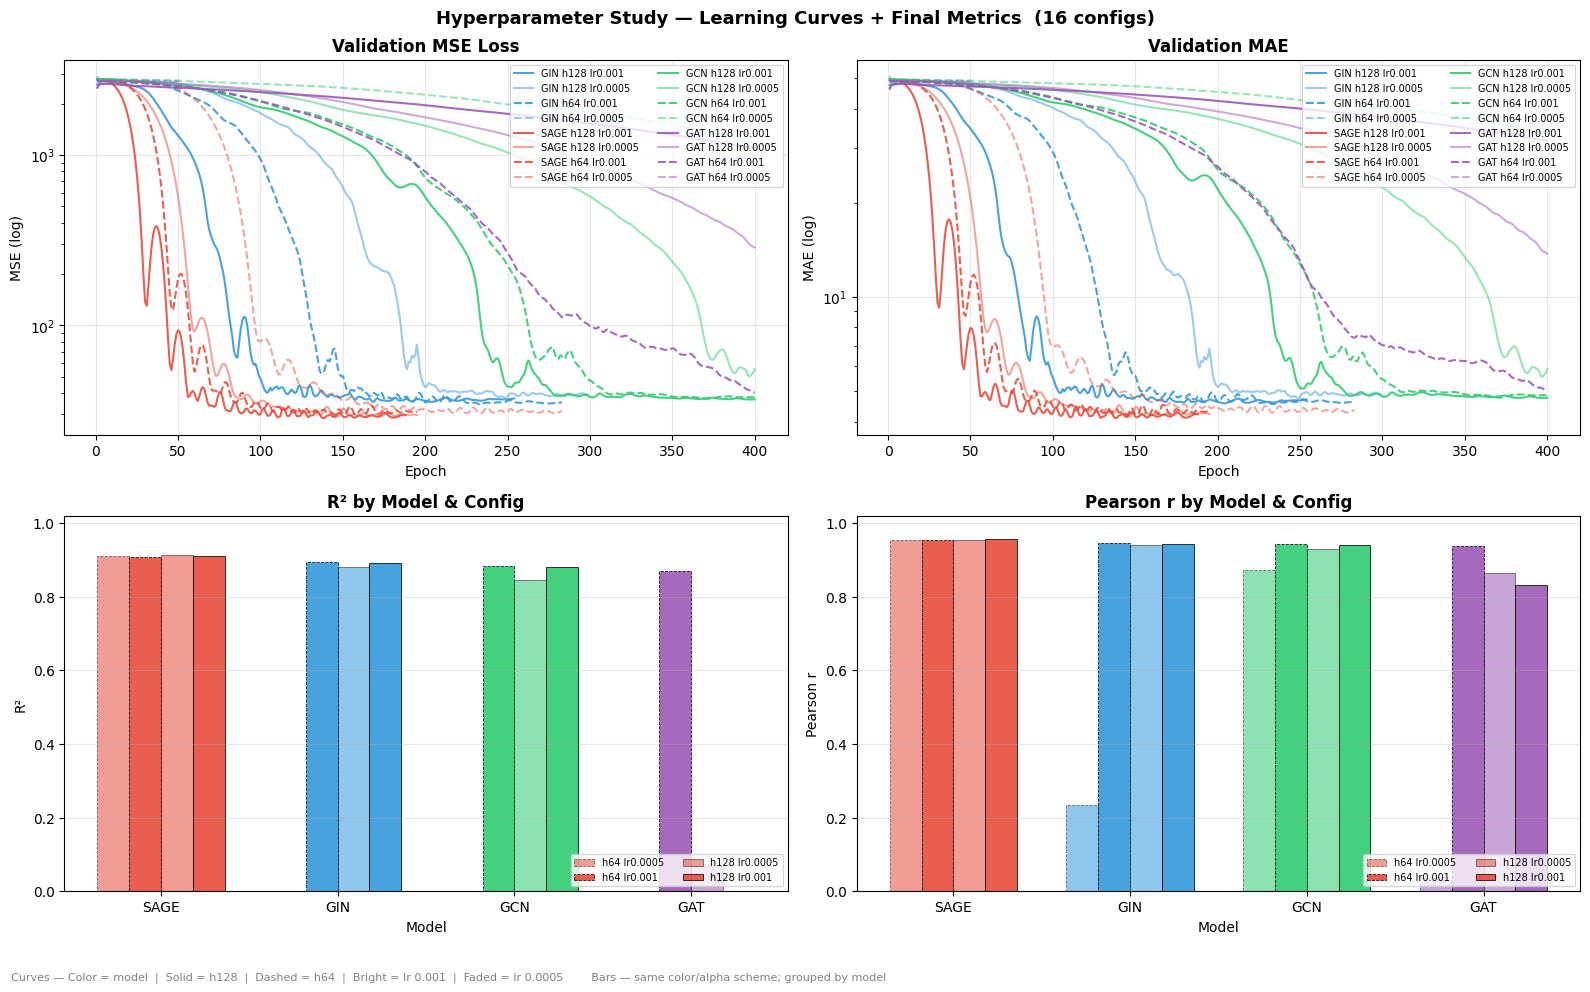

In [ ]:
# ── Learning curves + R²/Pearson summary bars ─────────────────────────────
model_colors  = {'GIN': '#3498db', 'SAGE': '#e74c3c', 'GCN': '#2ecc71', 'GAT': '#9b59b6'}
hidden_styles = {128: '-', 64: '--'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
ax_mse, ax_mae, ax_r2, ax_pear = axes.flatten()

# ── Panels 1 & 2 : per-epoch curves ───────────────────────────────────────
for run_name, hist in histories.items():
    parts  = run_name.split('_')
    model  = parts[0]
    hidden = int(parts[1].replace('h', ''))
    lr     = float(parts[2].replace('lr', ''))

    ep  = [h['epoch'] for h in hist]
    vl  = [h['val']   for h in hist]
    mae = [h['mae']   for h in hist]

    kw = dict(
        color     = model_colors.get(model, 'gray'),
        linestyle = hidden_styles.get(hidden, '-'),
        alpha     = 0.9 if lr == 0.001 else 0.5,
        linewidth = 1.5,
        label     = f'{model} h{hidden} lr{lr}',
    )
    ax_mse.plot(ep, vl,  **kw)
    ax_mae.plot(ep, mae, **kw)

for ax, title, ylabel in [
    (ax_mse, 'Validation MSE Loss', 'MSE (log)'),
    (ax_mae, 'Validation MAE',      'MAE (log)'),
]:
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.set_yscale('log')
    ax.legend(fontsize=7, ncol=2, loc='upper right')
    ax.grid(True, alpha=0.3)

# ── Panels 3 & 4 : grouped bar charts from df ─────────────────────────────
models      = df['Model'].unique()
hiddens     = sorted(df['Hidden'].unique())
lrs         = sorted(df['LR'].unique())
combos      = [(h, lr) for h in hiddens for lr in lrs]
n_combos    = len(combos)
bar_width   = 0.18
x_positions = np.arange(len(models))

for i, (hidden, lr) in enumerate(combos):
    subset     = df[(df['Hidden'] == hidden) & (df['LR'] == lr)]
    subset     = subset.set_index('Model').reindex(models)
    offset     = (i - n_combos / 2 + 0.5) * bar_width
    alpha_val  = 0.9 if lr == 0.001 else 0.55
    edge_ls    = '-' if hidden == 128 else '--'
    bar_colors = [model_colors.get(m, 'gray') for m in models]
    label      = f'h{hidden} lr{lr}'

    ax_r2.bar(
        x_positions + offset, subset['R2'],
        width=bar_width, color=bar_colors, alpha=alpha_val,
        edgecolor='black', linewidth=0.6, linestyle=edge_ls, label=label)
    ax_pear.bar(
        x_positions + offset, subset['Pearson'],
        width=bar_width, color=bar_colors, alpha=alpha_val,
        edgecolor='black', linewidth=0.6, linestyle=edge_ls, label=label)

for ax, title, ylabel in [
    (ax_r2,   'R² by Model & Config',       'R²'),
    (ax_pear, 'Pearson r by Model & Config', 'Pearson r'),
]:
    ax.set_xticks(x_positions)
    ax.set_xticklabels(models, fontsize=10)
    ax.set_xlabel('Model'); ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=7, ncol=2, loc='lower right')
    ax.grid(True, alpha=0.3, axis='y')

# ── ylim using actual df column names ─────────────────────────────────────
ax_r2.set_ylim(max(0, df['R2'].min() - 0.05), 1.02)
ax_pear.set_ylim(max(0, df['Pearson'].min() - 0.05), 1.02)

# ── Legend guide ──────────────────────────────────────────────────────────
fig.text(0.01, 0.01,
         'Curves — Color = model  |  Solid = h128  |  Dashed = h64  |  '
         'Bright = lr 0.001  |  Faded = lr 0.0005        '
         'Bars — same color/alpha scheme; grouped by model',
         fontsize=8, color='gray')

plt.suptitle(
    f'Hyperparameter Study — Learning Curves + Final Metrics  ({len(histories)} configs)',
    fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('fig_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

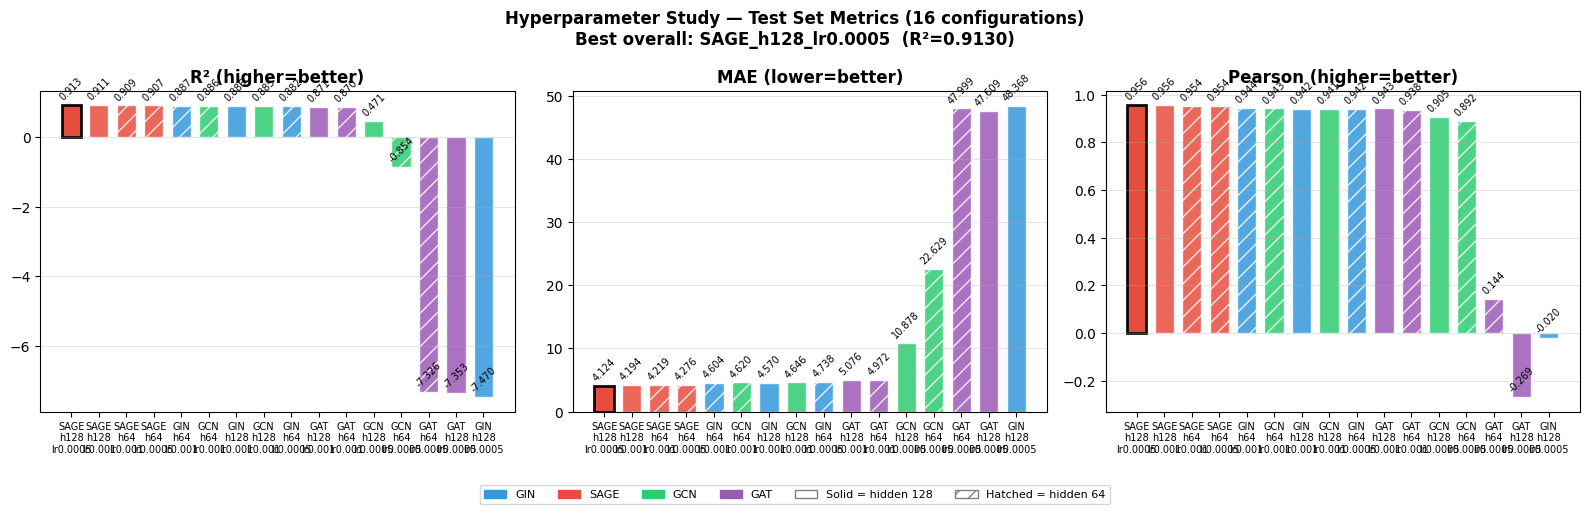

In [ ]:
# ── Bar chart: all hyperparameter configurations ──────────────────────────
model_colors  = {'GIN':'#3498db','SAGE':'#e74c3c','GCN':'#2ecc71','GAT':'#9b59b6'}
hidden_hatch  = {128: '', 64: '//'}   # solid = 128, hatched = 64

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_cfg = [
    ('R2',      'R² (higher=better)',      False),
    ('MAE',     'MAE (lower=better)',       True),
    ('Pearson', 'Pearson (higher=better)',  False),
]

x_labels = [f"{r['Model']}\nh{int(r['Hidden'])}\nlr{r['LR']}"
             for _, r in df.iterrows()]
x_pos    = np.arange(len(df))

for ax, (col, title, lower_better) in zip(axes, metrics_cfg):
    vals  = df[col].tolist()
    cols  = [model_colors.get(r['Model'], 'gray') for _, r in df.iterrows()]
    hatch = [hidden_hatch.get(int(r['Hidden']), '') for _, r in df.iterrows()]

    for i, (v, c, h) in enumerate(zip(vals, cols, hatch)):
        bar = ax.bar(x_pos[i], v, color=c, alpha=0.85,
                     edgecolor='white', hatch=h, width=0.7)

    # Highlight best bar with a black border
    best_i = int(np.argmin(vals) if lower_better else np.argmax(vals))
    ax.bar(x_pos[best_i], vals[best_i],
           color=cols[best_i], alpha=0.95,
           edgecolor='black', linewidth=2, hatch=hatch[best_i], width=0.7)

    # Value labels
    for i, v in enumerate(vals):
        ax.text(x_pos[i], v + (max(vals)-min(vals))*0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=7)
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

# ── Color legend ──────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=model_colors['GIN'],  label='GIN'),
    mpatches.Patch(color=model_colors['SAGE'], label='SAGE'),
    mpatches.Patch(color=model_colors['GCN'],  label='GCN'),
    mpatches.Patch(color=model_colors['GAT'],  label='GAT'),
    mpatches.Patch(facecolor='white', edgecolor='gray',
                   label='Solid = hidden 128'),
    mpatches.Patch(facecolor='white', edgecolor='gray',
                   hatch='//', label='Hatched = hidden 64'),
]
fig.legend(handles=legend_patches, loc='lower center',
           ncol=6, fontsize=8, bbox_to_anchor=(0.5, -0.02))

plt.suptitle(f'Hyperparameter Study — Test Set Metrics ({len(df)} configurations)\n'
             f'Best overall: {best_key}  (R²={df.iloc[0]["R2"]:.4f})',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('fig_architecture_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Fo test set

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# AD-HOC TEST SET EVALUATION — all 16 configurations
# ══════════════════════════════════════════════════════════════════════════

df_test = df.sort_values('R2', ascending=False).reset_index(drop=True)
medals  = {0: '🥇', 1: '🥈', 2: '🥉'}

print('=' * 82)
print('  📊 TEST SET RESULTS — ALL CONFIGURATIONS')
print('=' * 82)
print(f"  {'Rank':<6} {'Model':<8} {'Hidden':<8} {'LR':<8} "
      f"{'MAE':<14} {'RMSE':<14} {'R²':<12} {'Pearson'}")
print(f"  {'-'*80}")

for i, row in df_test.iterrows():
    medal  = medals.get(i, f'   {i+1:2d}')
    status = '✅' if row['R2'] > 0.85 else ('⚠️' if row['R2'] > 0 else '❌')
    print(f"  {medal:<6} {row['Model']:<8} {int(row['Hidden']):<8} {row['LR']:<8} "
          f"{row['MAE']:<14.6f} {row['RMSE']:<14.6f} "
          f"{row['R2']:<12.6f} {row['Pearson']:.6f}  {status}")

print('=' * 82)

# ── Best per model ─────────────────────────────────────────────────────────
print(f'\n  📌 BEST PER MODEL (by test R²)')
print(f"  {'Model':<8} {'Hidden':<8} {'LR':<8} {'MAE':<14} {'RMSE':<14} "
      f"{'R²':<12} {'Pearson'}")
print(f"  {'-'*75}")
for model_name in ['GIN', 'SAGE', 'GCN', 'GAT']:
    sub = df_test[df_test['Model'] == model_name]
    if sub.empty:
        print(f"  {model_name:<8} ❌ all configurations failed")
        continue
    r = sub.iloc[0]
    print(f"  {model_name:<8} {int(r['Hidden']):<8} {r['LR']:<8} "
          f"{r['MAE']:<14.6f} {r['RMSE']:<14.6f} "
          f"{r['R2']:<12.6f} {r['Pearson']:.6f}")

print('=' * 82)

# ── Summary stats ──────────────────────────────────────────────────────────
valid = df_test[df_test['R2'] > 0]
print(f'\n  📈 SUMMARY (valid configs only, R² > 0):  {len(valid)}/{len(df_test)}')
print(f"  {'Metric':<12} {'Best':>10} {'Worst':>10} {'Mean':>10} {'Std':>10}")
print(f"  {'-'*48}")
for col, lower_better in [('R2', False), ('MAE', True), ('RMSE', True), ('Pearson', False)]:
    best  = valid[col].min() if lower_better else valid[col].max()
    worst = valid[col].max() if lower_better else valid[col].min()
    print(f"  {col:<12} {best:>10.4f} {worst:>10.4f} "
          f"{valid[col].mean():>10.4f} {valid[col].std():>10.4f}")

print('=' * 82)
print(f'\n  🏆 Overall best : {df_test.iloc[0]["Model"]} '
      f'h{int(df_test.iloc[0]["Hidden"])} lr{df_test.iloc[0]["LR"]}  →  '
      f'R²={df_test.iloc[0]["R2"]:.6f}  '
      f'MAE={df_test.iloc[0]["MAE"]:.6f}')

  📊 TEST SET RESULTS — ALL CONFIGURATIONS
  Rank   Model    Hidden   LR       MAE            RMSE           R²           Pearson
  --------------------------------------------------------------------------------
  🥇      SAGE     128      0.0005   4.123803       5.223522       0.912993     0.956056  ✅
  🥈      SAGE     128      0.001    4.194364       5.281710       0.911044     0.955604  ✅
  🥉      SAGE     64       0.001    4.218596       5.336090       0.909203     0.954184  ✅
      4  SAGE     64       0.0005   4.276433       5.411226       0.906628     0.953664  ✅
      5  GIN      64       0.001    4.603649       5.945900       0.887265     0.944168  ✅
      6  GCN      64       0.001    4.619946       5.967357       0.886450     0.942936  ✅
      7  GIN      128      0.001    4.570312       5.983732       0.885826     0.942174  ✅
      8  GCN      128      0.001    4.645664       6.001168       0.885159     0.941427  ✅
      9  GIN      64       0.0005   4.737700       6.088261 

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# SAVE TEST SET RESULTS TO EXCEL
# ══════════════════════════════════════════════════════════════════════════

import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

wb = openpyxl.Workbook()

# ── Styles ─────────────────────────────────────────────────────────────────
header_font  = Font(bold=True, color="FFFFFF", size=11)
header_fill  = PatternFill("solid", fgColor="1F3864")
gold_fill    = PatternFill("solid", fgColor="FFD700")
silver_fill  = PatternFill("solid", fgColor="C0C0C0")
bronze_fill  = PatternFill("solid", fgColor="CD7F32")
good_fill    = PatternFill("solid", fgColor="C6EFCE")
warn_fill    = PatternFill("solid", fgColor="FFEB9C")
bad_fill     = PatternFill("solid", fgColor="FFC7CE")
center       = Alignment(horizontal="center", vertical="center")
thin         = Border(
    left=Side(style="thin"),  right=Side(style="thin"),
    top=Side(style="thin"),   bottom=Side(style="thin"))

model_fills = {
    'GIN':  PatternFill("solid", fgColor="DDEBF7"),
    'SAGE': PatternFill("solid", fgColor="E2EFDA"),
    'GCN':  PatternFill("solid", fgColor="FFF2CC"),
    'GAT':  PatternFill("solid", fgColor="FCE4D6"),
}

def write_header(ws, columns, col_widths):
    for ci, (name, width) in enumerate(zip(columns, col_widths), 1):
        cell = ws.cell(row=1, column=ci, value=name)
        cell.font      = header_font
        cell.fill      = header_fill
        cell.alignment = center
        cell.border    = thin
        ws.column_dimensions[get_column_letter(ci)].width = width
    ws.freeze_panes = "A2"
    ws.row_dimensions[1].height = 20

def write_cell(ws, row, col, value, fill=None, bold=False):
    cell = ws.cell(row=row, column=col, value=value)
    cell.alignment = center
    cell.border    = thin
    if fill:  cell.fill = fill
    if bold:  cell.font = Font(bold=True, size=10)
    return cell


# ══════════════════════════════════════════════════════════════════════════
# SHEET 1 — All 16 configurations ranked by R²
# ══════════════════════════════════════════════════════════════════════════
ws1 = wb.active
ws1.title = "All Configurations"

cols1   = ['Rank', 'Model', 'Hidden', 'LR', 'MAE', 'RMSE', 'R2', 'Pearson', 'Status']
widths1 = [8, 10, 10, 10, 16, 16, 14, 14, 12]
write_header(ws1, cols1, widths1)

for i, row in df_test.iterrows():
    er  = i + 2
    r2  = row['R2']

    # Row fill based on rank or R²
    if i == 0:   row_fill = gold_fill
    elif i == 1: row_fill = silver_fill
    elif i == 2: row_fill = bronze_fill
    elif r2 > 0.85: row_fill = good_fill
    elif r2 > 0:    row_fill = warn_fill
    else:           row_fill = bad_fill

    status = '✅ Good' if r2 > 0.85 else ('⚠️ Weak' if r2 > 0 else '❌ Failed')

    write_cell(ws1, er, 1, i+1,                  row_fill, bold=(i<3))
    write_cell(ws1, er, 2, row['Model'],          row_fill, bold=(i<3))
    write_cell(ws1, er, 3, int(row['Hidden']),    row_fill)
    write_cell(ws1, er, 4, row['LR'],             row_fill)
    write_cell(ws1, er, 5, round(row['MAE'],6),   row_fill)
    write_cell(ws1, er, 6, round(row['RMSE'],6),  row_fill)
    write_cell(ws1, er, 7, round(row['R2'],6),    row_fill, bold=(i==0))
    write_cell(ws1, er, 8, round(row['Pearson'],6), row_fill)
    write_cell(ws1, er, 9, status,                row_fill)


# ══════════════════════════════════════════════════════════════════════════
# SHEET 2 — Best per model
# ══════════════════════════════════════════════════════════════════════════
ws2 = wb.create_sheet("Best per Model")

cols2   = ['Model', 'Hidden', 'LR', 'MAE', 'RMSE', 'R2', 'Pearson']
widths2 = [10, 10, 10, 16, 16, 14, 14]
write_header(ws2, cols2, widths2)

er = 2
for model_name in ['GIN', 'SAGE', 'GCN', 'GAT']:
    sub = df_test[df_test['Model'] == model_name]
    mf  = model_fills.get(model_name, PatternFill("solid", fgColor="FFFFFF"))
    if sub.empty:
        write_cell(ws2, er, 1, model_name, mf, bold=True)
        write_cell(ws2, er, 2, '❌ failed', mf)
        er += 1
        continue
    r = sub.iloc[0]
    write_cell(ws2, er, 1, r['Model'],          mf, bold=True)
    write_cell(ws2, er, 2, int(r['Hidden']),    mf)
    write_cell(ws2, er, 3, r['LR'],             mf)
    write_cell(ws2, er, 4, round(r['MAE'],6),   mf)
    write_cell(ws2, er, 5, round(r['RMSE'],6),  mf)
    write_cell(ws2, er, 6, round(r['R2'],6),    mf, bold=True)
    write_cell(ws2, er, 7, round(r['Pearson'],6), mf)
    er += 1


# ══════════════════════════════════════════════════════════════════════════
# SHEET 3 — Summary statistics
# ══════════════════════════════════════════════════════════════════════════
ws3 = wb.create_sheet("Summary Statistics")

cols3   = ['Metric', 'Best', 'Worst', 'Mean', 'Std', 'Median']
widths3 = [14, 14, 14, 14, 14, 14]
write_header(ws3, cols3, widths3)

valid = df_test[df_test['R2'] > 0]
er = 2
for col, lower_better in [('R2',False),('MAE',True),('RMSE',True),('Pearson',False)]:
    best  = valid[col].min() if lower_better else valid[col].max()
    worst = valid[col].max() if lower_better else valid[col].min()
    mf    = model_fills.get('SAGE')
    write_cell(ws3, er, 1, col,                    mf, bold=True)
    write_cell(ws3, er, 2, round(best,6),          good_fill)
    write_cell(ws3, er, 3, round(worst,6),         warn_fill)
    write_cell(ws3, er, 4, round(valid[col].mean(),6), mf)
    write_cell(ws3, er, 5, round(valid[col].std(),6),  mf)
    write_cell(ws3, er, 6, round(valid[col].median(),6), mf)
    er += 1

# ── Note row ───────────────────────────────────────────────────────────────
ws3.cell(row=er+1, column=1,
         value=f'Valid configs (R²>0): {len(valid)}/{len(df_test)}').font = Font(italic=True)
ws3.cell(row=er+2, column=1,
         value=f'Best overall: {df_test.iloc[0]["Model"]} '
               f'h{int(df_test.iloc[0]["Hidden"])} '
               f'lr{df_test.iloc[0]["LR"]} '
               f'→ R²={df_test.iloc[0]["R2"]:.6f}').font = Font(bold=True, color="1F3864")


# ── Save ───────────────────────────────────────────────────────────────────
path = 'test_set_results.xlsx'
wb.save(path)
print(f'✅ Saved: {path}')
print(f'   Sheet 1 — All Configurations : {len(df_test)} runs ranked by R²')
print(f'   Sheet 2 — Best per Model     : top config for each architecture')
print(f'   Sheet 3 — Summary Statistics : mean/std/best/worst per metric')
print(f'\n🏆 Best: {df_test.iloc[0]["Model"]} '
      f'h{int(df_test.iloc[0]["Hidden"])} '
      f'lr{df_test.iloc[0]["LR"]}  →  '
      f'R²={df_test.iloc[0]["R2"]:.6f}  '
      f'MAE={df_test.iloc[0]["MAE"]:.6f}')

✅ Saved: test_set_results.xlsx
   Sheet 1 — All Configurations : 16 runs ranked by R²
   Sheet 2 — Best per Model     : top config for each architecture
   Sheet 3 — Summary Statistics : mean/std/best/worst per metric

🏆 Best: SAGE h128 lr0.0005  →  R²=0.912993  MAE=4.123803


## 6. XAI Comparative Study
### Applied on the best model

> All three explainers (GNNExplainer | GraphMask | ZORRO) run on the **same** frozen best model.

In [ ]:
test_indices   = data.test_mask.nonzero(as_tuple=True)[0].tolist()
patient_target = test_indices[20]
patient_name   = idx_to_name.get(patient_target, f'idx_{patient_target}')

with torch.no_grad():
    pred_score = best_model(data.x, data.edge_index,
                            data.edge_weight)[patient_target].item()
true_score = data.y[patient_target].item()

print(f'🎯 Patient : {patient_name}  (idx={patient_target})')
print(f'   Model   : {best_name}')
print(f'   Pred    : {pred_score:.4f}')
print(f'   True    : {true_score:.4f}')
print(f'   Error   : {abs(pred_score-true_score):.4f}')

🎯 Patient : U_00120  (idx=133)
   Model   : SAGE
   Pred    : 77.1594
   True    : 71.9234
   Error   : 5.2360


### Explainer 1 — GNNExplainer *(Ying et al., NeurIPS 2019)*

In [ ]:
class ModelWrapper(nn.Module):
    """Freeze edge_weight so GNNExplainer only masks x and edge_index."""
    def __init__(self, model, ew):
        super().__init__()
        self.model = model
        self.ew    = ew
    def forward(self, x, edge_index):
        return self.model(x, edge_index, self.ew)

wrapped = ModelWrapper(best_model, data.edge_weight).to(device)
wrapped.eval()

gnn_explainer = Explainer(
    model=wrapped,
    algorithm=GNNExplainer(epochs=200, lr=0.01),
    explanation_type='model',
    model_config=ModelConfig(mode='regression',
                             task_level='node', return_type='raw'),
    node_mask_type='attributes',
    edge_mask_type='object',
    threshold_config=dict(threshold_type='hard', value=0.0)  # keep all raw values
)

def explain_gnnexplainer(node_idx):
    exp = gnn_explainer(x=data.x, edge_index=data.edge_index, index=node_idx)
    return {'node_mask': exp.node_mask[node_idx].cpu().detach().numpy(),
            'edge_mask': exp.edge_mask.cpu().detach().numpy()}

print('✅ GNNExplainer ready (threshold=0.0, full continuous mask)')

✅ GNNExplainer ready (threshold=0.0, full continuous mask)


### Explainer 2 — GraphMask *(Schlichtkrull et al., ICLR 2021)*

In [ ]:
class GraphMaskModel(nn.Module):
    def __init__(self, n_edges, n_feats):
        super().__init__()
        self.el = nn.Parameter(torch.full((n_edges,), -2.0))
        self.fl = nn.Parameter(torch.full((n_feats,), -2.0))
    def forward(self):
        return torch.sigmoid(self.el), torch.sigmoid(self.fl)

def explain_graphmask(node_idx, epochs=300, lr=0.005,
                       lam_e=0.5, lam_f=0.3):
    best_model.eval()
    mm  = GraphMaskModel(data.edge_index.shape[1],
                         data.x.shape[1]).to(device)
    opt = torch.optim.Adam(mm.parameters(), lr=lr)
    with torch.no_grad():
        tgt = best_model(data.x, data.edge_index,
                         data.edge_weight)[node_idx].detach()
    best_l, best_s = float('inf'), None
    for _ in range(epochs):
        opt.zero_grad()
        em, fm = mm()
        pred   = best_model(data.x * fm.unsqueeze(0),
                            data.edge_index,
                            data.edge_weight * em)[node_idx]
        loss   = (pred-tgt)**2 + lam_e*em.mean() + lam_f*fm.mean()
        loss.backward(); opt.step()
        if loss.item() < best_l:
            best_l = loss.item(); best_s = deepcopy(mm.state_dict())
    mm.load_state_dict(best_s)
    em, fm = mm()
    return {'node_mask': fm.cpu().detach().numpy(),
            'edge_mask': em.cpu().detach().numpy()}

print('✅ GraphMask ready (λ_e=0.5, λ_f=0.3)')

✅ GraphMask ready (λ_e=0.5, λ_f=0.3)


### Explainer 3 — ZORRO *(Funke et al., ECML 2022)*

In [ ]:
def explain_zorro(node_idx, epsilon=8.0, n_runs=30, seed=42):
    """epsilon=8.0 ≈ 8% of 0-100 score range — tight enough to find minimal subsets."""
    best_model.eval()
    rng = np.random.RandomState(seed)
    nf  = data.x.shape[1]
    with torch.no_grad():
        orig = best_model(data.x, data.edge_index,
                          data.edge_weight)[node_idx].item()
    counts = np.zeros(nf)
    for _ in range(n_runs):
        order, sel = rng.permutation(nf), []
        for f in order:
            sel.append(f)
            xm = torch.zeros_like(data.x)
            for ff in sel: xm[:,ff] = data.x[:,ff]
            with torch.no_grad():
                p = best_model(xm, data.edge_index,
                               data.edge_weight)[node_idx].item()
            if abs(p - orig) < epsilon: break
        for f in sel: counts[f] += 1
    nm = counts / n_runs
    el = data.edge_index.t().cpu().numpy()
    em = np.zeros(data.edge_index.shape[1])
    for i,(u,v) in enumerate(el):
        if u==node_idx or v==node_idx: em[i] = nm.mean()
    return {'node_mask': nm, 'edge_mask': em, 'uncertainty': 1.0-nm}

print('✅ ZORRO ready (ε=8.0, n_runs=30)')

✅ ZORRO ready (ε=8.0, n_runs=30)


In [ ]:
print(f'\n🎯 Patient: {patient_name}  (idx={patient_target})')
print(f'   Model  : {best_name}\n')
print('⏳ GNNExplainer ...')
exp_gnn       = explain_gnnexplainer(patient_target)
print('⏳ GraphMask ...')
exp_graphmask = explain_graphmask(patient_target)
print('⏳ ZORRO ...')
exp_zorro     = explain_zorro(patient_target)

explanations = {'GNNExplainer': exp_gnn,
                'GraphMask':    exp_graphmask,
                'ZORRO':        exp_zorro}
print('\n✅ All three explainers done.')


🎯 Patient: U_00120  (idx=133)
   Model  : SAGE

⏳ GNNExplainer ...
⏳ GraphMask ...
⏳ ZORRO ...

✅ All three explainers done.


## 7. XAI Evaluation Metrics

In [ ]:
def fidelity(node_mask, node_idx, thr=0.3):
    """Node-level masking: only perturb the target patient, keep neighbors intact."""
    best_model.eval()
    with torch.no_grad():
        orig = best_model(data.x, data.edge_index,
                          data.edge_weight)[node_idx].item()
    imp = node_mask > thr
    xp  = data.x.clone(); xp[node_idx, ~imp] = 0.0
    xm  = data.x.clone(); xm[node_idx,  imp] = 0.0
    with torch.no_grad():
        fp = abs(orig - best_model(xp, data.edge_index,
                                   data.edge_weight)[node_idx].item())
        fm = abs(orig - best_model(xm, data.edge_index,
                                   data.edge_weight)[node_idx].item())
    char = 2*fp*fm/(fp+fm) if fp+fm > 0 else 0.0
    return fp, fm, char

def sparsity(nm, em, thr=0.3):
    return (nm>thr).mean(), (em>thr).mean()

def stability(fn, n_pairs=10, seed=42):
    order = np.argsort(data.y[test_indices].cpu().numpy())
    nodes = [test_indices[i] for i in order]
    mses  = []
    for i in range(min(n_pairs, len(nodes)-1)):
        try:
            e1=fn(int(nodes[i])); e2=fn(int(nodes[i+1]))
            mses.append(((e1['node_mask']-e2['node_mask'])**2).mean())
        except: pass
    return (np.mean(mses),np.std(mses)) if mses else (float('nan'),float('nan'))

def rand_baseline(node_idx, n_runs=30, thr=0.3, seed=42):
    rng = np.random.RandomState(seed)
    best_model.eval()
    with torch.no_grad():
        orig = best_model(data.x, data.edge_index,
                          data.edge_weight)[node_idx].item()
    fp_l, fm_l = [], []
    for _ in range(n_runs):
        imp = rng.rand(data.x.shape[1]) > thr
        xp  = data.x.clone(); xp[node_idx,~imp] = 0.0
        xm  = data.x.clone(); xm[node_idx, imp] = 0.0
        with torch.no_grad():
            fp_l.append(abs(orig - best_model(xp, data.edge_index,
                                              data.edge_weight)[node_idx].item()))
            fm_l.append(abs(orig - best_model(xm, data.edge_index,
                                              data.edge_weight)[node_idx].item()))
    return np.mean(fp_l), np.mean(fm_l)

print('✅ Evaluation functions defined')

✅ Evaluation functions defined


In [ ]:
fid_res, spar_res, stab_res = {}, {}, {}

print('='*72)
print('  📐 FIDELITY + SPARSITY')
print('='*72)
print(f"  {'Explainer':<16} {'Fid+':<10} {'Fid-':<10} "
      f"{'Char':<10} {'SparFeat':<11} {'SparEdge'}")
print(f"  {'-'*70}")
for name, exp in explanations.items():
    fp,fm,cs = fidelity(exp['node_mask'], patient_target)
    fr,er    = sparsity(exp['node_mask'], exp['edge_mask'])
    fid_res[name]  = {'fid_plus':fp,'fid_minus':fm,'char':cs}
    spar_res[name] = {'feat_ratio':fr,'edge_ratio':er}
    print(f'  {name:<16} {fp:<10.4f} {fm:<10.4f} {cs:<10.4f} {fr:<11.2%} {er:.2%}')
print('='*72)

print('\n  🔁 STABILITY (pairwise MSE, lower=better)')
fns = {
    'GNNExplainer': explain_gnnexplainer,
    'GraphMask':    lambda i: explain_graphmask(i, epochs=100),
    'ZORRO':        lambda i: explain_zorro(i, epsilon=8.0, n_runs=10),
}
for name, fn in fns.items():
    print(f'  ⏳ {name}...')
    m,s = stability(fn)
    stab_res[name] = {'mean':m,'std':s}
    print(f'     {name:<16} MSE={m:.4f} ± {s:.4f}')

rfp, rfm = rand_baseline(patient_target)
print(f'\n  🎲 Random baseline   Fid+={rfp:.4f}   Fid-={rfm:.4f}')
for name,r in fid_res.items():
    tag = '✅ BETTER' if r['fid_plus'] > rfp else '❌ not better'
    print(f'     {name}: {tag} than random on Fidelity+  '
          f'({r["fid_plus"]:.4f} vs {rfp:.4f})')

  📐 FIDELITY + SPARSITY
  Explainer        Fid+       Fid-       Char       SparFeat    SparEdge
  ----------------------------------------------------------------------
  GNNExplainer     0.0000     31.9531    0.0000     94.74%      0.27%
  GraphMask        0.9907     30.0829    1.9183     73.68%      0.27%
  ZORRO            0.0000     31.9531    0.0000     100.00%     0.01%

  🔁 STABILITY (pairwise MSE, lower=better)
  ⏳ GNNExplainer...
     GNNExplainer     MSE=0.0000 ± 0.0000
  ⏳ GraphMask...
     GraphMask        MSE=0.0023 ± 0.0005
  ⏳ ZORRO...
     ZORRO            MSE=0.0070 ± 0.0034

  🎲 Random baseline   Fid+=9.5858   Fid-=19.3469
     GNNExplainer: ❌ not better than random on Fidelity+  (0.0000 vs 9.5858)
     GraphMask: ❌ not better than random on Fidelity+  (0.9907 vs 9.5858)
     ZORRO: ❌ not better than random on Fidelity+  (0.0000 vs 9.5858)


New visualisation ( predicates and futures)

📌 Node attributes  (5): ['age', 'weight', 'height', 'mood', 'stressLevel']
📌 Graph predicates (30): ['HighBloodOxygen', 'HighBodyFat', 'HighCalorieIntake', 'HighDeepSleepDuration', 'HighHeartRate'] ... (total 30)
🚫 Excluded: {'MediumScore', 'LowScore', 'HighScore'}


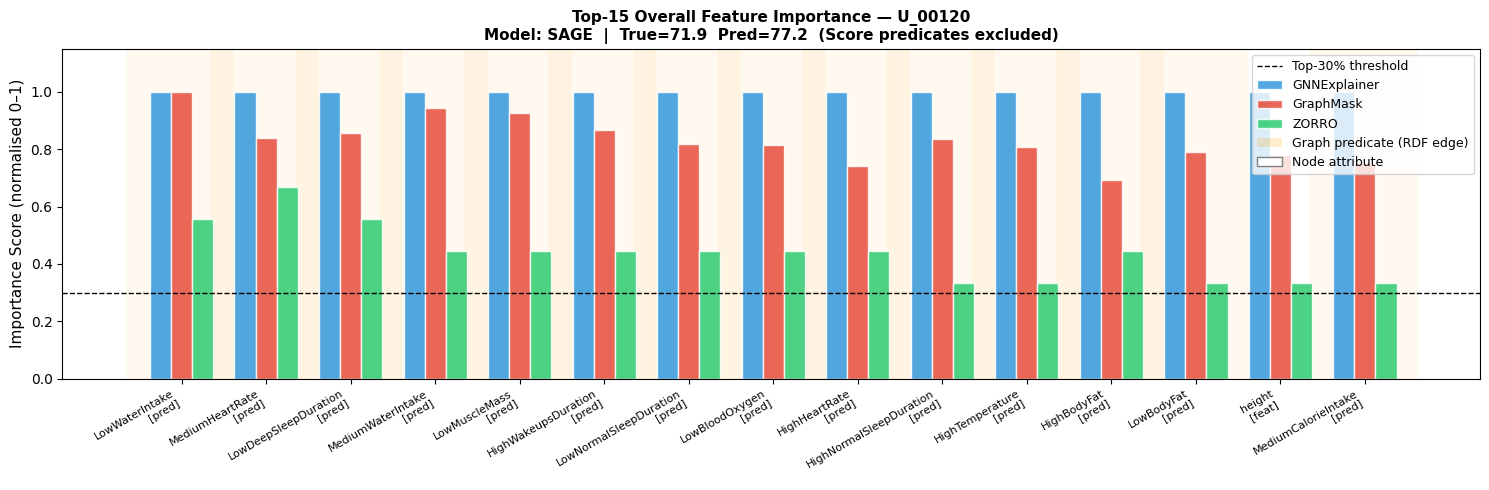

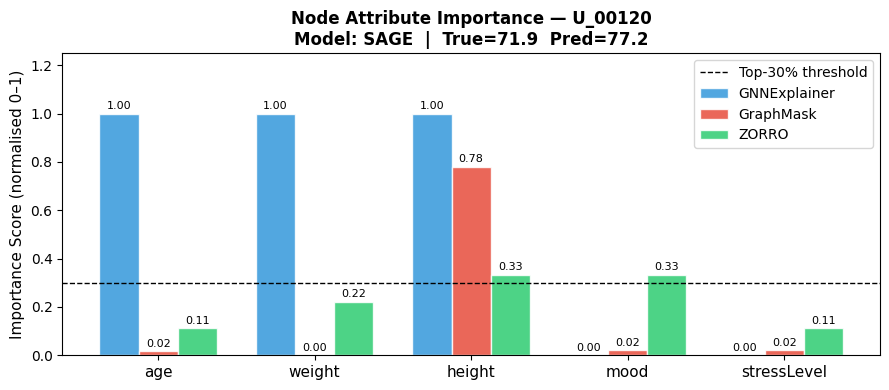


📊 Node Attribute Importance:
  Attribute       GNNExplainer    GraphMask       ZORRO           
  ----------------------------------------------------------------
  age             1.0000          0.0160          0.1111          
  weight          1.0000          0.0000          0.2222          
  height          1.0000          0.7805          0.3333          
  mood            0.0000          0.0212          0.3333          
  stressLevel     0.0000          0.0212          0.1111          


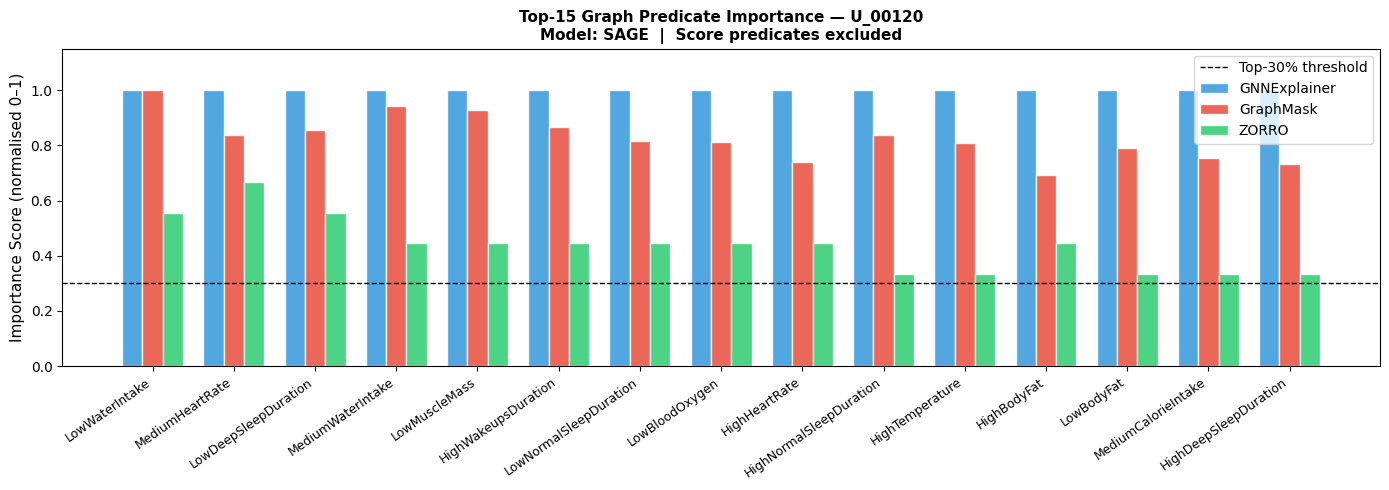

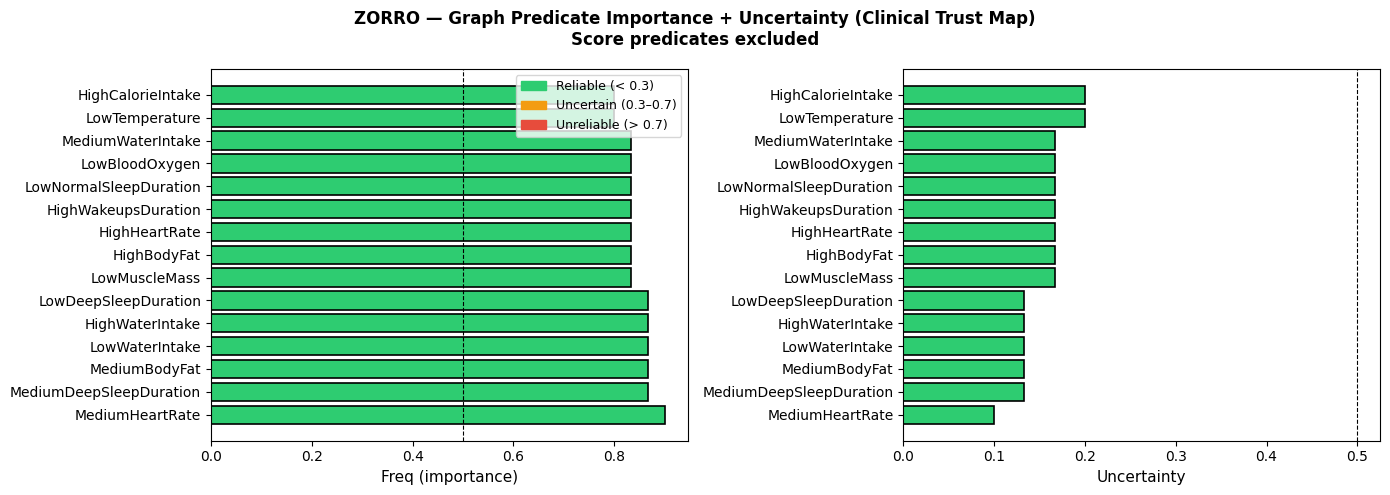

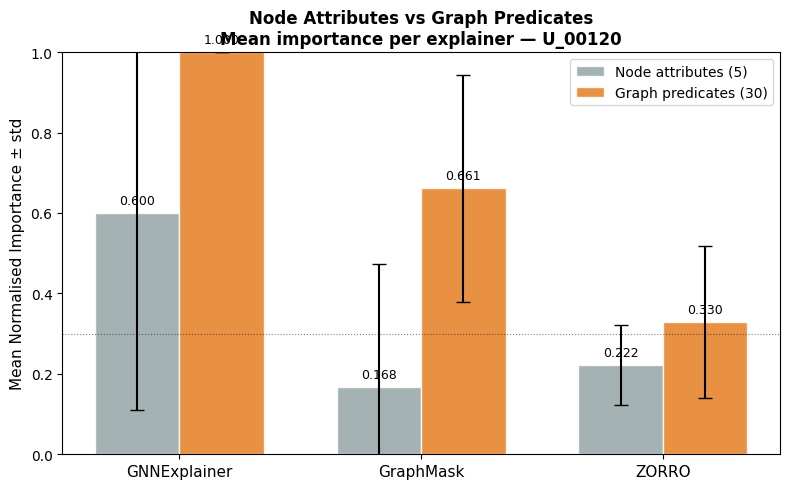


📊 Predicate / Attribute importance ratio:
  GNNExplainer    : 1.67x  (pred=1.000, attr=0.600)
  GraphMask       : 3.94x  (pred=0.661, attr=0.168)
  ZORRO           : 1.48x  (pred=0.330, attr=0.222)


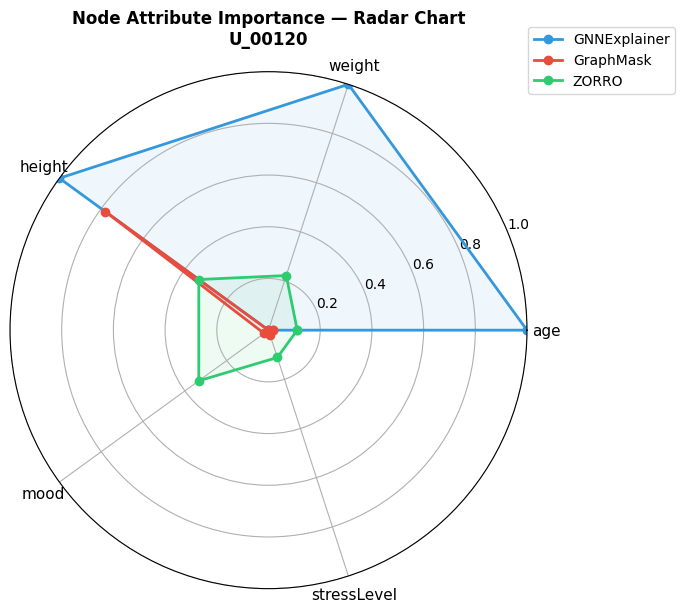

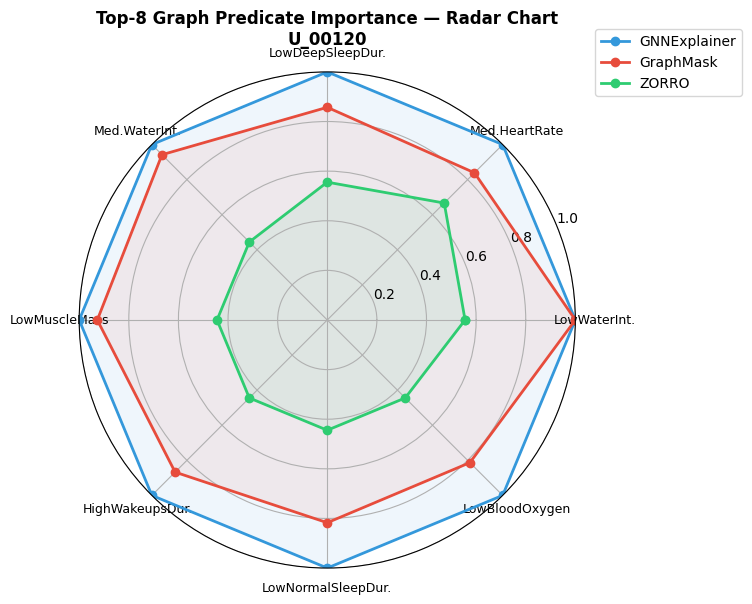

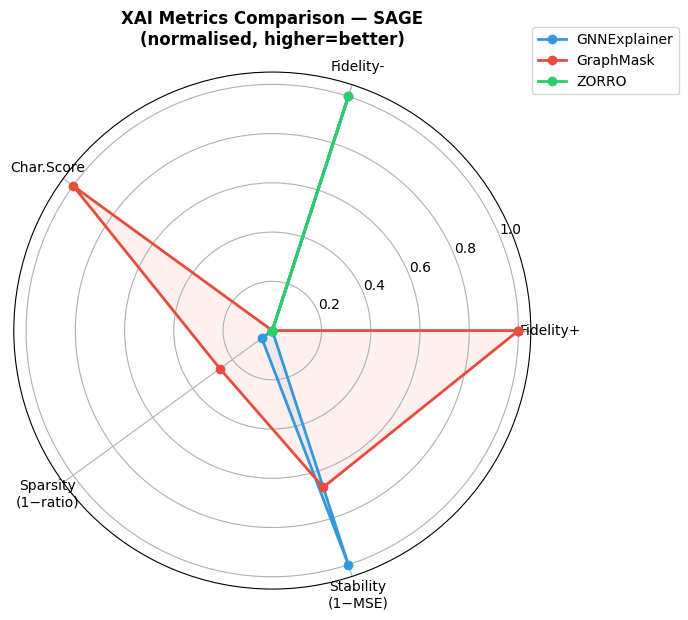

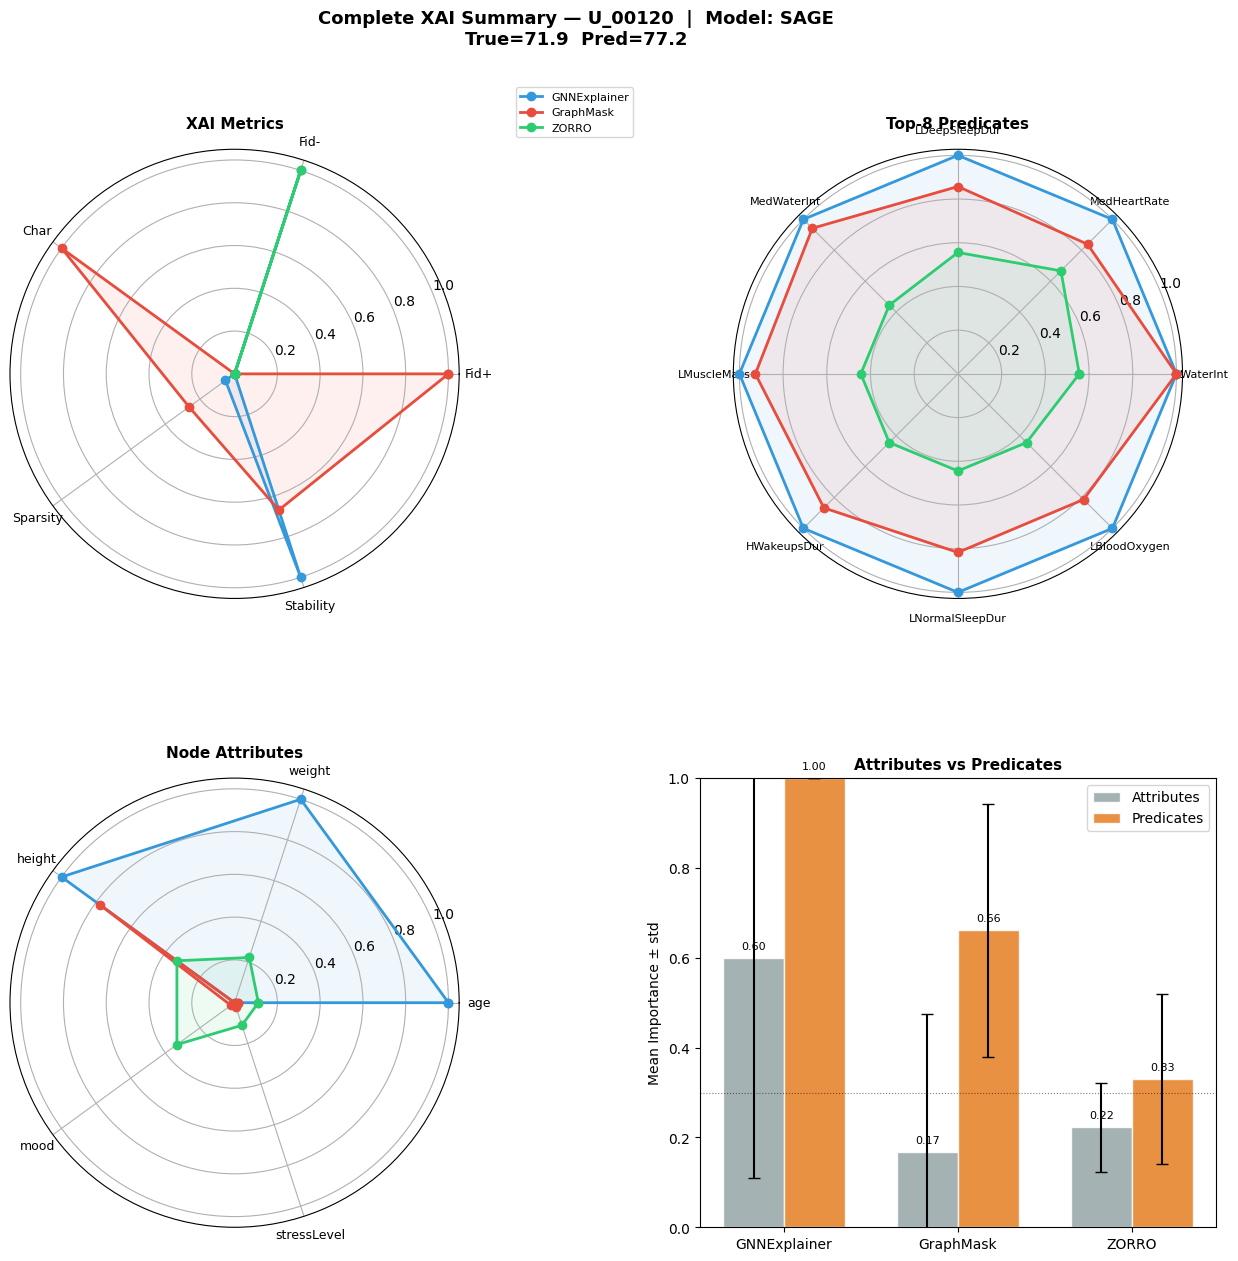


  🤝 PREDICATE CONSENSUS ANALYSIS

  ✅ Agreed by ALL 3 (top-30%):
  Predicate                     GNNExplainer  GraphMask     ZORRO           Avg
  ----------------------------------------------------------------------
  HighWakeupsDuration           1.000         0.867         0.444           0.771

  🔶 Agreed by exactly 2:
  LowWaterIntake                1.000         1.000         0.556           0.852
  MediumHeartRate               1.000         0.839         0.667           0.835
  LowDeepSleepDuration          1.000         0.857         0.556           0.804
  HighHeartRate                 1.000         0.741         0.444           0.729
  HighNormalSleepDuration       1.000         0.836         0.333           0.723
  HighBodyFat                   1.000         0.693         0.444           0.712


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ══════════════════════════════════════════════════════════════════════════
# SETUP — Feature classification
# ══════════════════════════════════════════════════════════════════════════

BASIC_FEATURES     = {'age', 'weight', 'height', 'mood', 'stressLevel'}
EXCLUDE_PREDICATES = {'LowScore', 'HighScore', 'MediumScore'}

def feature_type(name):
    return 'attribute' if name in BASIC_FEATURES else 'predicate'

attr_idx   = [i for i, n in enumerate(feature_names) if feature_type(n) == 'attribute']
pred_idx   = [i for i, n in enumerate(feature_names)
              if feature_type(n) == 'predicate' and n not in EXCLUDE_PREDICATES]
attr_names = [feature_names[i] for i in attr_idx]
pred_names = [feature_names[i] for i in pred_idx]

print(f'📌 Node attributes  ({len(attr_idx)}): {attr_names}')
print(f'📌 Graph predicates ({len(pred_idx)}): {pred_names[:5]} ... (total {len(pred_idx)})')
print(f'🚫 Excluded: {EXCLUDE_PREDICATES}')

XAI_COLORS = {'GNNExplainer': '#3498db', 'GraphMask': '#e74c3c', 'ZORRO': '#2ecc71'}

def normalize(mask):
    mn, mx = mask.min(), mask.max()
    return (mask - mn) / (mx - mn + 1e-8)

def get_norm_masks(explanations, feature_names):
    return {m: normalize(explanations[m]['node_mask'][:len(feature_names)])
            for m in explanations}


# ══════════════════════════════════════════════════════════════════════════
# FIG 1 — Top-15 overall (attributes + predicates, scores excluded)
# ══════════════════════════════════════════════════════════════════════════
def plot_importance_overall(explanations, feature_names, top_k=15):
    methods    = list(explanations.keys())
    norm_masks = get_norm_masks(explanations, feature_names)

    valid_idx   = [i for i, n in enumerate(feature_names) if n not in EXCLUDE_PREDICATES]
    valid_names = [feature_names[i] for i in valid_idx]

    # Re-index norm_masks to valid_idx
    vm = {m: norm_masks[m][valid_idx] for m in methods}
    avg   = np.mean([vm[m] for m in methods], axis=0)
    top_i = np.argsort(avg)[::-1][:top_k]
    top_n = [valid_names[i] for i in top_i]
    types = [feature_type(n) for n in top_n]

    x, w = np.arange(top_k), 0.25
    fig, ax = plt.subplots(figsize=(15, 5))

    for i, method in enumerate(methods):
        vals = vm[method][top_i]
        ax.bar(x + i*w, vals, w, label=method,
               color=XAI_COLORS[method], alpha=0.85, edgecolor='white')

    for xi, ftype in enumerate(types):
        if ftype == 'predicate':
            ax.axvspan(xi - 0.4, xi + 3*w + 0.1, alpha=0.06, color='orange', zorder=0)

    ax.set_xticks(x + w)
    ax.set_xticklabels(
        [f'{n}\n[pred]' if feature_type(n) == 'predicate' else f'{n}\n[feat]'
         for n in top_n], rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Importance Score (normalised 0–1)', fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.axhline(0.3, color='black', linestyle='--', lw=1, label='Top-30% threshold')

    handles, labels = ax.get_legend_handles_labels()
    handles += [mpatches.Patch(facecolor='orange', alpha=0.2, label='Graph predicate (RDF edge)'),
                mpatches.Patch(facecolor='white', edgecolor='gray', label='Node attribute')]
    ax.legend(handles=handles, fontsize=9, loc='upper right')
    ax.set_title(
        f'Top-{top_k} Overall Feature Importance — {patient_name}\n'
        f'Model: {best_name}  |  True={true_score:.1f}  Pred={pred_score:.1f}  '
        f'(Score predicates excluded)',
        fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.savefig('fig_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_importance_overall(explanations, feature_names)


# ══════════════════════════════════════════════════════════════════════════
# FIG 2 — Node attributes only (5 basic features)
# ══════════════════════════════════════════════════════════════════════════
def plot_attribute_importance(explanations, feature_names):
    methods    = list(explanations.keys())
    norm_masks = get_norm_masks(explanations, feature_names)

    x, w = np.arange(len(attr_names)), 0.25
    fig, ax = plt.subplots(figsize=(9, 4))

    for i, method in enumerate(methods):
        vals = [norm_masks[method][j] for j in attr_idx]
        bars = ax.bar(x + i*w, vals, w, label=method,
                      color=XAI_COLORS[method], alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x + w)
    ax.set_xticklabels(attr_names, fontsize=11)
    ax.set_ylabel('Importance Score (normalised 0–1)', fontsize=11)
    ax.set_ylim(0, 1.25)
    ax.axhline(0.3, color='black', linestyle='--', lw=1, label='Top-30% threshold')
    ax.legend(fontsize=10)
    ax.set_title(
        f'Node Attribute Importance — {patient_name}\n'
        f'Model: {best_name}  |  True={true_score:.1f}  Pred={pred_score:.1f}',
        fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.savefig('fig_attribute_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n📊 Node Attribute Importance:')
    print(f"  {'Attribute':<16}" + ''.join(f'{m:<16}' for m in methods))
    print(f"  {'-'*64}")
    for j, name in zip(attr_idx, attr_names):
        scores = [f'{norm_masks[method][j]:.4f}' for method in methods]
        print(f"  {name:<16}" + ''.join(f'{s:<16}' for s in scores))

plot_attribute_importance(explanations, feature_names)


# ══════════════════════════════════════════════════════════════════════════
# FIG 3 — Top-15 graph predicates only (scores excluded)
# ══════════════════════════════════════════════════════════════════════════
def plot_predicate_importance(explanations, feature_names, top_k=15):
    methods    = list(explanations.keys())
    norm_masks = get_norm_masks(explanations, feature_names)

    avg_scores = {feature_names[i]: np.mean([norm_masks[m][i] for m in methods])
                  for i in pred_idx}
    top_preds  = sorted(avg_scores, key=avg_scores.get, reverse=True)[:top_k]

    x, w = np.arange(top_k), 0.25
    fig, ax = plt.subplots(figsize=(14, 5))

    for i, method in enumerate(methods):
        vals = [norm_masks[method][feature_names.index(p)] for p in top_preds]
        ax.bar(x + i*w, vals, w, label=method,
               color=XAI_COLORS[method], alpha=0.85, edgecolor='white')

    ax.set_xticks(x + w)
    ax.set_xticklabels(top_preds, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Importance Score (normalised 0–1)', fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.axhline(0.3, color='black', linestyle='--', lw=1, label='Top-30% threshold')
    ax.legend(fontsize=10)
    ax.set_title(
        f'Top-{top_k} Graph Predicate Importance — {patient_name}\n'
        f'Model: {best_name}  |  Score predicates excluded',
        fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.savefig('fig_predicate_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_predicate_importance(explanations, feature_names)


# ══════════════════════════════════════════════════════════════════════════
# FIG 4 — ZORRO: predicates only (scores excluded)
# ══════════════════════════════════════════════════════════════════════════
def plot_predicate_zorro(exp_zorro, feature_names, top_k=15):
    nm  = exp_zorro['node_mask'][:len(feature_names)]
    unc = exp_zorro['uncertainty'][:len(feature_names)]
    p_nm  = np.array([nm[i]  for i in pred_idx])
    p_unc = np.array([unc[i] for i in pred_idx])

    order = np.argsort(p_nm)[::-1][:top_k]
    names = [pred_names[i] for i in order]
    m_top = p_nm[order]
    u_top = p_unc[order]

    unc_colors = ['#2ecc71' if u < 0.3 else ('#f39c12' if u < 0.7 else '#e74c3c')
                  for u in u_top]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        'ZORRO — Graph Predicate Importance + Uncertainty (Clinical Trust Map)\n'
        'Score predicates excluded',
        fontsize=12, fontweight='bold')

    for ax, vals, xlabel in zip(axes, [m_top, u_top],
                                ['Freq (importance)', 'Uncertainty']):
        ax.barh(names, vals, color=unc_colors, edgecolor='black', linewidth=1.2)
        ax.set_xlabel(xlabel, fontsize=11)
        ax.axvline(0.5, color='black', linestyle='--', lw=0.8)

    patches = [mpatches.Patch(color='#2ecc71', label='Reliable (< 0.3)'),
               mpatches.Patch(color='#f39c12', label='Uncertain (0.3–0.7)'),
               mpatches.Patch(color='#e74c3c', label='Unreliable (> 0.7)')]
    axes[0].legend(handles=patches, fontsize=9)
    plt.tight_layout()
    plt.savefig('fig_predicate_zorro.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_predicate_zorro(exp_zorro, feature_names)


# ══════════════════════════════════════════════════════════════════════════
# FIG 5 — Attribute vs Predicate mean importance
# ══════════════════════════════════════════════════════════════════════════
def plot_attr_vs_pred(explanations, feature_names):
    methods    = list(explanations.keys())
    norm_masks = get_norm_masks(explanations, feature_names)

    attr_means, pred_means = [], []
    attr_stds,  pred_stds  = [], []

    for method in methods:
        nm = norm_masks[method]
        a  = [nm[i] for i in attr_idx]
        p  = [nm[i] for i in pred_idx]
        attr_means.append(np.mean(a)); attr_stds.append(np.std(a))
        pred_means.append(np.mean(p)); pred_stds.append(np.std(p))

    x, w = np.arange(len(methods)), 0.35
    fig, ax = plt.subplots(figsize=(8, 5))

    bars_a = ax.bar(x - w/2, attr_means, w, yerr=attr_stds,
                    label='Node attributes (5)', color='#95a5a6',
                    alpha=0.85, edgecolor='white', capsize=5)
    bars_p = ax.bar(x + w/2, pred_means, w, yerr=pred_stds,
                    label=f'Graph predicates ({len(pred_idx)})', color='#e67e22',
                    alpha=0.85, edgecolor='white', capsize=5)

    for bars in [bars_a, bars_p]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.015,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(methods, fontsize=11)
    ax.set_ylabel('Mean Normalised Importance ± std', fontsize=11)
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=10)
    ax.axhline(0.3, color='black', linestyle=':', lw=0.8, alpha=0.5)
    ax.set_title(
        f'Node Attributes vs Graph Predicates\n'
        f'Mean importance per explainer — {patient_name}',
        fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.savefig('fig_attr_vs_pred.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n📊 Predicate / Attribute importance ratio:')
    for i, method in enumerate(methods):
        ratio = pred_means[i] / (attr_means[i] + 1e-8)
        print(f'  {method:<16}: {ratio:.2f}x  '
              f'(pred={pred_means[i]:.3f}, attr={attr_means[i]:.3f})')

plot_attr_vs_pred(explanations, feature_names)


# ══════════════════════════════════════════════════════════════════════════
# FIG 6 — Radar chart: ATTRIBUTES (per explainer across 5 attributes)
# ══════════════════════════════════════════════════════════════════════════
def plot_radar_attributes(explanations, feature_names):
    methods    = list(explanations.keys())
    colors     = [XAI_COLORS[m] for m in methods]
    norm_masks = get_norm_masks(explanations, feature_names)
    cats       = attr_names
    N          = len(cats)
    angles     = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    for method, color in zip(methods, colors):
        vals = [norm_masks[method][j] for j in attr_idx] + \
               [norm_masks[method][attr_idx[0]]]
        ax.plot(angles, vals, 'o-', lw=2, color=color, label=method)
        ax.fill(angles, vals, alpha=0.08, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cats, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_title(
        f'Node Attribute Importance — Radar Chart\n{patient_name}',
        fontweight='bold', fontsize=12, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
    plt.tight_layout()
    plt.savefig('fig_radar_attributes.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_radar_attributes(explanations, feature_names)


# ══════════════════════════════════════════════════════════════════════════
# FIG 7 — Radar chart: TOP-8 PREDICATES (per explainer)
# ══════════════════════════════════════════════════════════════════════════
def plot_radar_predicates(explanations, feature_names, top_k=8):
    methods    = list(explanations.keys())
    colors     = [XAI_COLORS[m] for m in methods]
    norm_masks = get_norm_masks(explanations, feature_names)

    # Select top-k predicates by average importance
    avg_scores = {feature_names[i]: np.mean([norm_masks[m][i] for m in methods])
                  for i in pred_idx}
    top_preds  = sorted(avg_scores, key=avg_scores.get, reverse=True)[:top_k]
    top_pidx   = [feature_names.index(p) for p in top_preds]

    N      = len(top_preds)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for method, color in zip(methods, colors):
        vals = [norm_masks[method][i] for i in top_pidx] + \
               [norm_masks[method][top_pidx[0]]]
        ax.plot(angles, vals, 'o-', lw=2, color=color, label=method)
        ax.fill(angles, vals, alpha=0.08, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(
        [p.replace('Medium','Med.').replace('Duration','Dur.')
          .replace('Intake','Int.') for p in top_preds],
        fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(
        f'Top-{top_k} Graph Predicate Importance — Radar Chart\n{patient_name}',
        fontweight='bold', fontsize=12, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
    plt.tight_layout()
    plt.savefig('fig_radar_predicates.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_radar_predicates(explanations, feature_names, top_k=8)


# ══════════════════════════════════════════════════════════════════════════
# FIG 8 — Radar chart: XAI METRICS comparison (existing)
# ══════════════════════════════════════════════════════════════════════════
def plot_radar_xai(fid_res, spar_res, stab_res):
    cats   = ['Fidelity+', 'Fidelity-', 'Char.Score',
               'Sparsity\n(1−ratio)', 'Stability\n(1−MSE)']
    names  = list(fid_res.keys())
    colors = [XAI_COLORS[n] for n in names]

    def norm(v):
        mn, mx = min(v), max(v)
        return [(x - mn) / (mx - mn + 1e-8) for x in v]

    fp  = norm([fid_res[n]['fid_plus']   for n in names])
    fm  = norm([fid_res[n]['fid_minus']  for n in names])
    cs  = norm([fid_res[n]['char']       for n in names])
    sp  = [1 - spar_res[n]['feat_ratio'] for n in names]
    st  = norm([1 - stab_res[n]['mean']  for n in names])

    angles = np.linspace(0, 2*np.pi, len(cats), endpoint=False).tolist() + [0]
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    for i, name in enumerate(names):
        vals = [fp[i], fm[i], cs[i], sp[i], st[i], fp[i]]
        ax.plot(angles, vals, 'o-', lw=2, color=colors[i], label=name)
        ax.fill(angles, vals, alpha=0.08, color=colors[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cats, fontsize=10)
    ax.set_title(
        f'XAI Metrics Comparison — {best_name}\n(normalised, higher=better)',
        fontsize=12, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
    plt.tight_layout()
    plt.savefig('fig_radar.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_radar_xai(fid_res, spar_res, stab_res)


# ══════════════════════════════════════════════════════════════════════════
# FIG 9 — Combined summary: 2×2 radar grid
#          TL: XAI metrics | TR: Predicate radar
#          BL: Attr radar  | BR: Attr vs Pred bar
# ══════════════════════════════════════════════════════════════════════════
def plot_combined_summary(explanations, feature_names, fid_res, spar_res, stab_res):
    methods    = list(explanations.keys())
    colors     = [XAI_COLORS[m] for m in methods]
    norm_masks = get_norm_masks(explanations, feature_names)

    fig = plt.figure(figsize=(16, 14))
    gs  = GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.4)

    # ── Top-left: XAI metrics radar ─────────────────────────────────────
    ax0 = fig.add_subplot(gs[0, 0], polar=True)
    cats_xai = ['Fid+', 'Fid-', 'Char', 'Sparsity', 'Stability']
    names_xai = list(fid_res.keys())

    def norm(v):
        mn, mx = min(v), max(v)
        return [(x-mn)/(mx-mn+1e-8) for x in v]

    fp = norm([fid_res[n]['fid_plus']   for n in names_xai])
    fm = norm([fid_res[n]['fid_minus']  for n in names_xai])
    cs = norm([fid_res[n]['char']       for n in names_xai])
    sp = [1-spar_res[n]['feat_ratio']   for n in names_xai]
    st = norm([1-stab_res[n]['mean']    for n in names_xai])

    ang_xai = np.linspace(0, 2*np.pi, 5, endpoint=False).tolist() + [0]
    for i, name in enumerate(names_xai):
        v = [fp[i], fm[i], cs[i], sp[i], st[i], fp[i]]
        ax0.plot(ang_xai, v, 'o-', lw=2, color=XAI_COLORS[name], label=name)
        ax0.fill(ang_xai, v, alpha=0.08, color=XAI_COLORS[name])
    ax0.set_xticks(ang_xai[:-1])
    ax0.set_xticklabels(cats_xai, fontsize=9)
    ax0.set_title('XAI Metrics', fontweight='bold', fontsize=11, pad=15)
    ax0.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=8)

    # ── Top-right: Top-8 predicate radar ────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 1], polar=True)
    avg_p   = {feature_names[i]: np.mean([norm_masks[m][i] for m in methods])
               for i in pred_idx}
    top8    = sorted(avg_p, key=avg_p.get, reverse=True)[:8]
    top8idx = [feature_names.index(p) for p in top8]
    ang_p   = np.linspace(0, 2*np.pi, 8, endpoint=False).tolist() + [0]

    for method, color in zip(methods, colors):
        v = [norm_masks[method][i] for i in top8idx] + [norm_masks[method][top8idx[0]]]
        ax1.plot(ang_p, v, 'o-', lw=2, color=color)
        ax1.fill(ang_p, v, alpha=0.08, color=color)
    ax1.set_xticks(ang_p[:-1])
    ax1.set_xticklabels(
        [p.replace('Medium','Med').replace('Duration','Dur')
          .replace('Intake','Int').replace('High','H').replace('Low','L')
         for p in top8], fontsize=8)
    ax1.set_title('Top-8 Predicates', fontweight='bold', fontsize=11, pad=15)

    # ── Bottom-left: Attribute radar ─────────────────────────────────────
    ax2   = fig.add_subplot(gs[1, 0], polar=True)
    ang_a = np.linspace(0, 2*np.pi, len(attr_names), endpoint=False).tolist() + [0]
    for method, color in zip(methods, colors):
        v = [norm_masks[method][j] for j in attr_idx] + [norm_masks[method][attr_idx[0]]]
        ax2.plot(ang_a, v, 'o-', lw=2, color=color)
        ax2.fill(ang_a, v, alpha=0.08, color=color)
    ax2.set_xticks(ang_a[:-1])
    ax2.set_xticklabels(attr_names, fontsize=9)
    ax2.set_title('Node Attributes', fontweight='bold', fontsize=11, pad=15)

    # ── Bottom-right: Attr vs Pred grouped bar ───────────────────────────
    ax3 = fig.add_subplot(gs[1, 1])
    attr_means = [np.mean([norm_masks[m][j] for j in attr_idx]) for m in methods]
    pred_means = [np.mean([norm_masks[m][j] for j in pred_idx]) for m in methods]
    attr_stds  = [np.std([norm_masks[m][j]  for j in attr_idx]) for m in methods]
    pred_stds  = [np.std([norm_masks[m][j]  for j in pred_idx]) for m in methods]

    x, w = np.arange(len(methods)), 0.35
    ax3.bar(x - w/2, attr_means, w, yerr=attr_stds,
            label='Attributes', color='#95a5a6', alpha=0.85,
            edgecolor='white', capsize=4)
    ax3.bar(x + w/2, pred_means, w, yerr=pred_stds,
            label='Predicates', color='#e67e22', alpha=0.85,
            edgecolor='white', capsize=4)
    for i, (am, pm) in enumerate(zip(attr_means, pred_means)):
        ax3.text(i - w/2, am + 0.02, f'{am:.2f}', ha='center', fontsize=8)
        ax3.text(i + w/2, pm + 0.02, f'{pm:.2f}', ha='center', fontsize=8)
    ax3.set_xticks(x)
    ax3.set_xticklabels(methods, fontsize=10)
    ax3.set_ylabel('Mean Importance ± std', fontsize=10)
    ax3.set_ylim(0, 1.0)
    ax3.legend(fontsize=10)
    ax3.axhline(0.3, color='black', linestyle=':', lw=0.8, alpha=0.5)
    ax3.set_title('Attributes vs Predicates', fontweight='bold', fontsize=11)

    fig.suptitle(
        f'Complete XAI Summary — {patient_name}  |  Model: {best_name}\n'
        f'True={true_score:.1f}  Pred={pred_score:.1f}',
        fontsize=13, fontweight='bold')

    plt.savefig('fig_xai_summary.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_combined_summary(explanations, feature_names, fid_res, spar_res, stab_res)


# ══════════════════════════════════════════════════════════════════════════
# CONSENSUS ANALYSIS — print which predicates all 3 agree on
# ══════════════════════════════════════════════════════════════════════════
def predicate_consensus(explanations, feature_names, top_pct=0.3):
    methods    = list(explanations.keys())
    norm_masks = get_norm_masks(explanations, feature_names)
    top_k      = max(1, int(len(pred_idx) * top_pct))

    top_per = {}
    for m in methods:
        scores = sorted(pred_idx, key=lambda i: norm_masks[m][i], reverse=True)
        top_per[m] = set(feature_names[i] for i in scores[:top_k])

    consensus_all = top_per[methods[0]] & top_per[methods[1]] & top_per[methods[2]]
    consensus_two = ((top_per[methods[0]] & top_per[methods[1]]) |
                     (top_per[methods[0]] & top_per[methods[2]]) |
                     (top_per[methods[1]] & top_per[methods[2]])) - consensus_all

    avg_all = {p: np.mean([norm_masks[m][feature_names.index(p)] for m in methods])
               for p in pred_names}

    print('\n' + '='*70)
    print('  🤝 PREDICATE CONSENSUS ANALYSIS')
    print('='*70)
    print(f'\n  ✅ Agreed by ALL 3 (top-{int(top_pct*100)}%):')
    print(f"  {'Predicate':<30}" + ''.join(f'{m:<14}' for m in methods) + '  Avg')
    print(f"  {'-'*70}")
    for p in sorted(consensus_all, key=lambda x: avg_all[x], reverse=True):
        scores = [f'{norm_masks[m][feature_names.index(p)]:.3f}' for m in methods]
        print(f"  {p:<30}" + ''.join(f'{s:<14}' for s in scores)
              + f'  {avg_all[p]:.3f}')

    print(f'\n  🔶 Agreed by exactly 2:')
    for p in sorted(consensus_two, key=lambda x: avg_all[x], reverse=True)[:8]:
        scores = [f'{norm_masks[m][feature_names.index(p)]:.3f}' for m in methods]
        print(f"  {p:<30}" + ''.join(f'{s:<14}' for s in scores)
              + f'  {avg_all[p]:.3f}')
    print('='*70)

predicate_consensus(explanations, feature_names)

In [ ]:
import os, shutil
from google.colab import files

# ── Where Colab saves figures by default ─────────────────────────────────
COLAB_ROOT = '/content'

# Exact names from plt.savefig() in your visualization cell
figure_files = [
    'fig_feature_importance.png',
    'fig_attribute_importance.png',
    'fig_predicate_importance.png',
    'fig_predicate_zorro.png',
    'fig_attr_vs_pred.png',
    'fig_radar_attributes.png',
    'fig_radar_predicates.png',
    'fig_radar.png',
    'fig_xai_summary.png',
    'fig_predicate_heatmap.png',
    'fig_learning_curves.png',
    'fig_architecture_comparison.png',
]

# ── Find each file (check /content/ and current dir) ─────────────────────
os.makedirs(f'{COLAB_ROOT}/overleaf_figures', exist_ok=True)

found, missing = [], []
for fname in figure_files:
    candidates = [
        f'{COLAB_ROOT}/{fname}',          # default Colab save location
        f'./{fname}',                      # current working directory
        f'/content/drive/MyDrive/{fname}', # Google Drive (if mounted)
    ]
    located = None
    for path in candidates:
        if os.path.exists(path):
            located = path
            break

    if located:
        dest = f'{COLAB_ROOT}/overleaf_figures/{fname}'
        shutil.copy(located, dest)
        found.append((fname, located))
    else:
        missing.append(fname)

# ── Report ────────────────────────────────────────────────────────────────
print('='*65)
print(f'  ✅ Found {len(found)} figures — names match LaTeX exactly')
print('='*65)
for fname, src in found:
    print(f'  {fname}')
    print(f'    ← {src}')

if missing:
    print(f'\n  ⚠️  {len(missing)} not found — re-run their plot cells:')
    for f in missing:
        print(f'    {f}')

# ── Zip and download ──────────────────────────────────────────────────────
zip_path = f'{COLAB_ROOT}/overleaf_figures'
shutil.make_archive(zip_path, 'zip', zip_path)
files.download(f'{zip_path}.zip')

print(f'\n⬇️  Downloading overleaf_figures.zip ({len(found)} files)')
print('   → Unzip → drag all .png files into your Overleaf project')
print('   → \\includegraphics{fig_radar.png} resolves immediately ✅')

  ✅ Found 11 figures — names match LaTeX exactly
  fig_feature_importance.png
    ← /content/fig_feature_importance.png
  fig_attribute_importance.png
    ← /content/fig_attribute_importance.png
  fig_predicate_importance.png
    ← /content/fig_predicate_importance.png
  fig_predicate_zorro.png
    ← /content/fig_predicate_zorro.png
  fig_attr_vs_pred.png
    ← /content/fig_attr_vs_pred.png
  fig_radar_attributes.png
    ← /content/fig_radar_attributes.png
  fig_radar_predicates.png
    ← /content/fig_radar_predicates.png
  fig_radar.png
    ← /content/fig_radar.png
  fig_xai_summary.png
    ← /content/fig_xai_summary.png
  fig_learning_curves.png
    ← /content/fig_learning_curves.png
  fig_architecture_comparison.png
    ← /content/fig_architecture_comparison.png

  ⚠️  1 not found — re-run their plot cells:
    fig_predicate_heatmap.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


⬇️  Downloading overleaf_figures.zip (11 files)
   → Unzip → drag all .png files into your Overleaf project
   → \includegraphics{fig_radar.png} resolves immediately ✅
